In [1]:
import cogsworth
import astropy.units as u
import astropy.constants as const
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord
from scipy.ndimage import gaussian_filter
import seaborn as sns

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [2]:
pop = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/binaries", parts=[])
pop.bpp["row_num"] = np.arange(len(pop.bpp))
pop.colour = "tab:blue"
pop.label = "Fiducial"

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(


In [45]:
pop = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/fiducial_part1")
pop.bpp["row_num"] = np.arange(len(pop.bpp))
pop.colour = "tab:blue"
pop.label = "Fiducial"

/mnt/home/twagg/codes/gala/src/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(

/mnt/home/twagg/codes/gala/src/gala/potential/potential/builtin/special.py:257: GalaFutureWarning: The MilkyWayPotential2022 class will be deprecated soon. Instead, use: MilkyWayPotential(version="v2") to get what is currently the MilkyWayPotential2022 class. Or, to always use the latest Milky Way model in Gala, you can call the class with no arguments MilkyWayPotential() or specify MilkyWayPotential(version="latest")
  warnings.warn(



# Rates

In [47]:
scale_up = 6e10 / pop.mass_binaries
scale_up

np.float64(3305.9336200480743)

In [48]:
n_ns = (pop.final_bpp["kstar_1"] == 13).sum() + (pop.final_bpp["kstar_2"] == 13).sum()
n_bh = (pop.final_bpp["kstar_1"] == 14).sum() + (pop.final_bpp["kstar_2"] == 14).sum()
print(f"Rates (unscaled)\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")
print(f"Rates (scaled)\n  Total: {(n_ns + n_bh) * scale_up:.1e}, NSs: {n_ns * scale_up:.1e}, BHs: {n_bh * scale_up:.1e}")

Rates (unscaled)
  Total: 200239, NSs: 144515, BHs: 55724
Rates (scaled)
  Total: 6.6e+08, NSs: 4.8e+08, BHs: 1.8e+08


Olejak+20 predicted 1.2e8 BHs, close!

# Spatial distributions

In [49]:
pop.final_pos

<Quantity [[  3.36294683,  -2.46513709,  -0.13134417],
           [  1.19541748,  -4.02648146,   0.26099107],
           [-13.23405112,  -7.51178369,   6.62869125],
           ...,
           [ -0.3457273 ,   1.81946463,  -2.57211602],
           [  0.24805213,   0.02542922,   0.61794188],
           [ -1.04436258,   2.24351203,   0.04623309]] kpc>

In [50]:
kinematics = helpers.get_kinematics([pop])
stars = cogsworth.sfh.SandersBinney2015(
    size=200000,
    **{
        "potential": pop.galactic_potential,
        "time_bins": 5,
        "verbose": True
    }
)

Pre-computing lookback time, guiding radius and frequency interpolations
Initiating sampling procedure
  Sampling 162038 stars from the thin_disc
    Sampling 19344 stars with lookback times between 0.00 Gyr and 2.00 Gyr
    Sampling 24823 stars with lookback times between 2.00 Gyr and 4.00 Gyr
    Sampling 30939 stars with lookback times between 4.00 Gyr and 6.00 Gyr
    Sampling 39357 stars with lookback times between 6.00 Gyr and 8.00 Gyr
    Sampling 47575 stars with lookback times between 8.00 Gyr and 10.00 Gyr
  Sampling 37962 stars from the thick_disc
    Sampling 37962 stars with lookback times between 10.00 Gyr and 12.00 Gyr


[ 29.32592701 208.37880208]
[ 6001.83451737 10654.14438569]


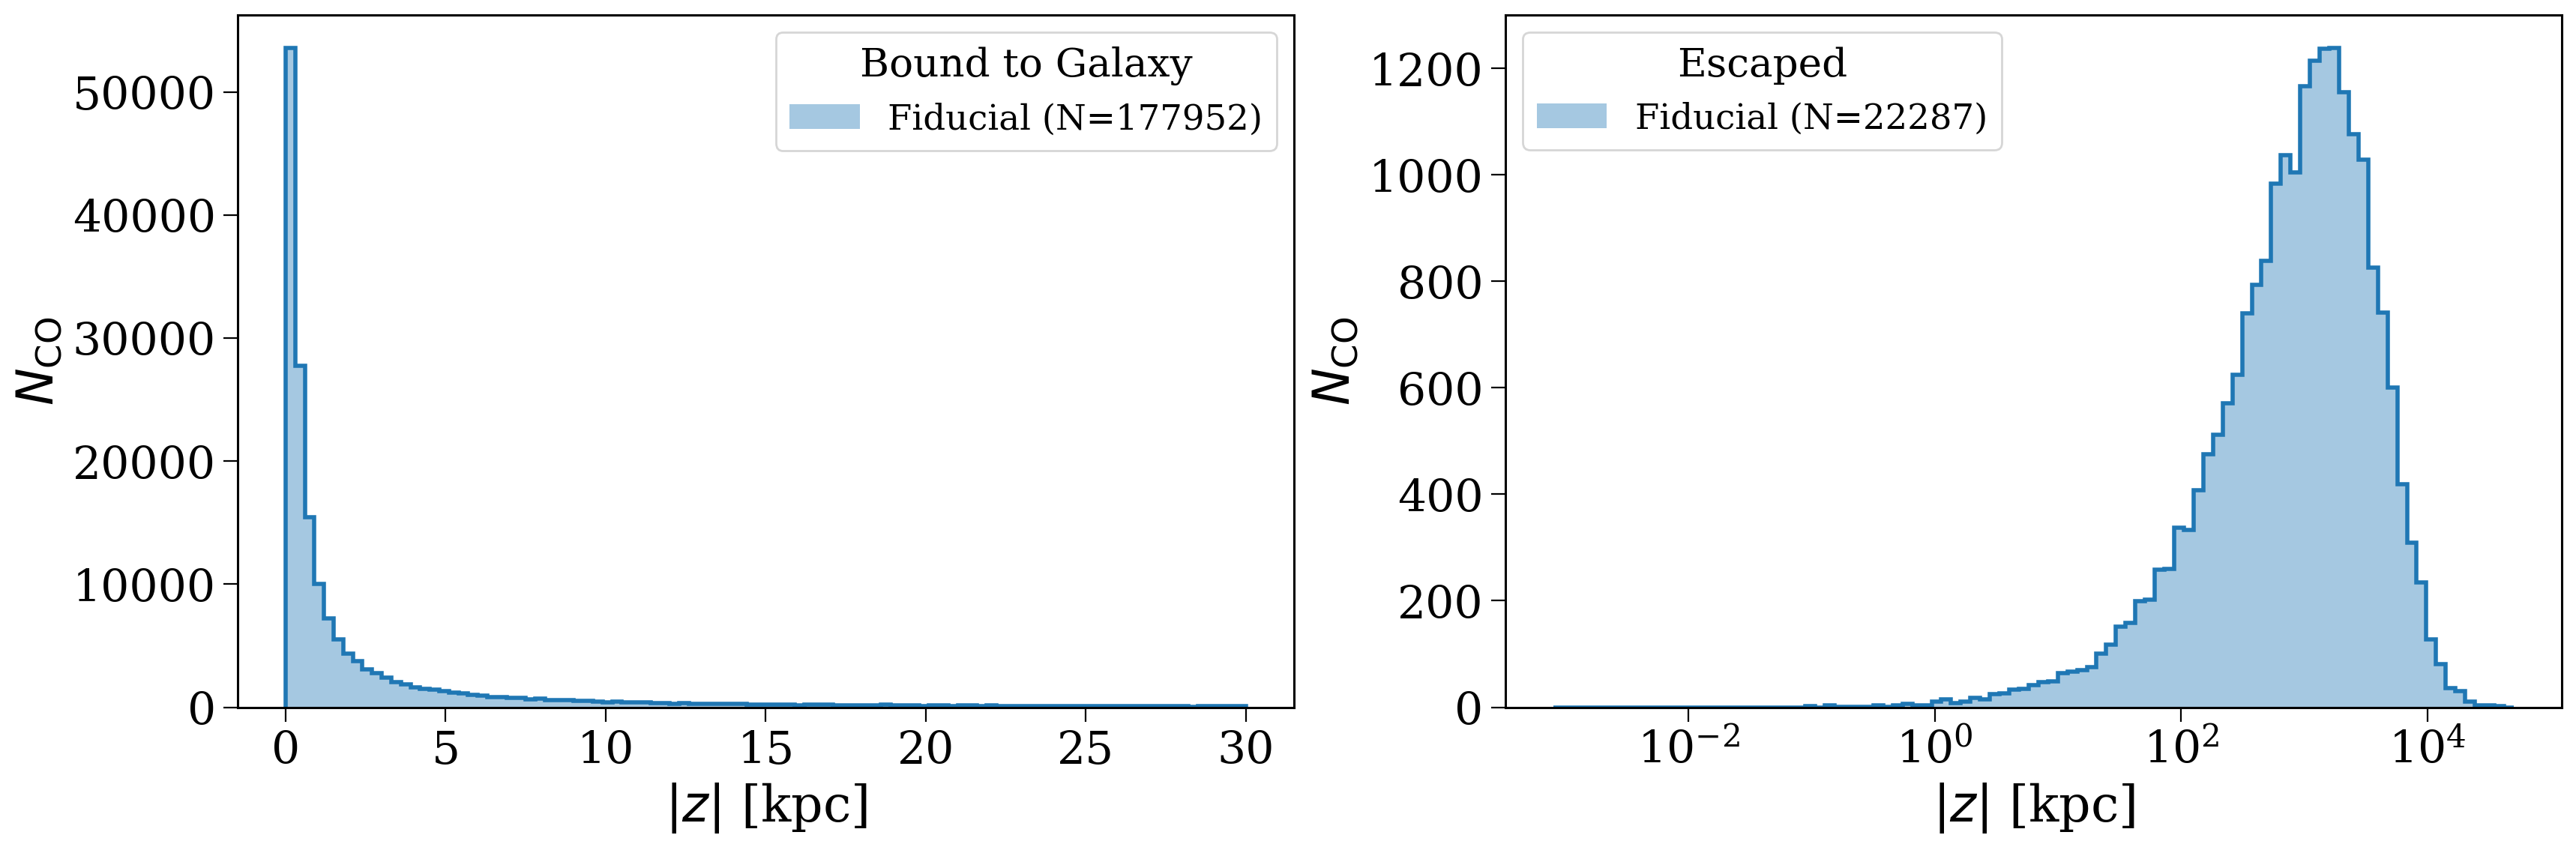

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

scales = ['linear', 'log']
bin_list = [np.linspace(0, 30, 101), np.geomspace(8e-4, 5e4, 100)]
labels = ['Bound to Galaxy', "Escaped"]

for ax, scale, bins, label in zip(axes, scales, bin_list, labels):
    co_pos = kinematics[pop.label]["pos"]["CO"]
    co_vel = kinematics[pop.label]["vel"]["CO"]

    co_V = np.linalg.norm(co_vel.to(u.km/u.s).value, axis=1)

    mask = co_V >= np.sqrt(-2 * pop.galactic_potential(co_pos.T)).to(u.km / u.s).value
    mask = mask if label == "Escaped" else ~mask

    print(np.percentile(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], [95, 99]))

    ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], bins=bins, histtype='step', lw=2, color=pop.colour)
    ax.hist(np.abs(co_pos[:, 2].to(u.kpc).value)[mask], bins=bins, alpha=0.4, color=pop.colour,
            label=f'{pop.label} (N={len(co_pos[mask])})')

    ax.set(
        xscale=scale,
        xlabel=r'$|z|$ [kpc]',
        ylabel=r'$N_{\rm CO}$',
    )
    ax.legend(title=label)
plt.show()

0.5465722720876414
0.31428988016767323


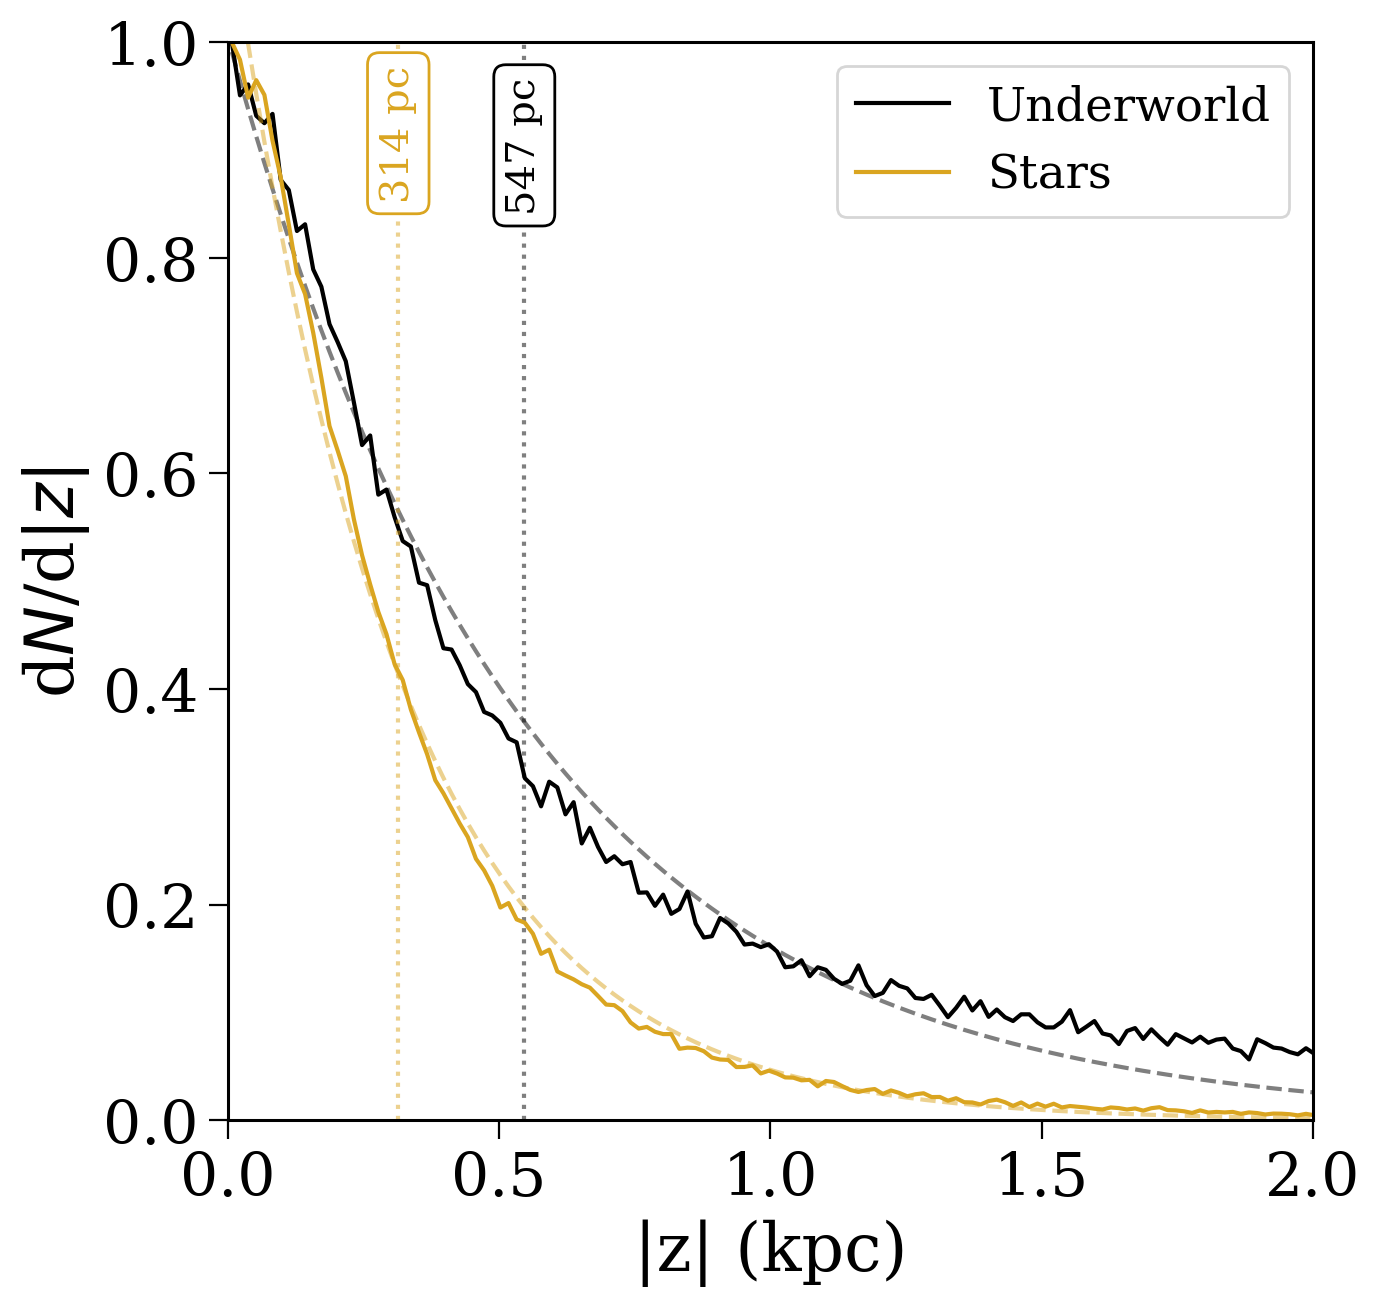

In [52]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour in zip(
    [kinematics["Fiducial"]["pos"]["CO"][:, 2], stars.z],
    ["Underworld", "Stars"],
    ["black", "goldenrod"]
):
    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(0, 2),
        ylim=(0, 1)
    )

plt.savefig("../plots/scale_height_underworld_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [53]:
reload(plotting)

def bootstrap_scale_height(z, n_samples=1000, **kwargs):
    scale_height_estimates = []
    n_components = kwargs.pop('n_components', 2)

    for _ in range(n_samples):
        sample_z = np.random.choice(z, size=len(z), replace=True)
        scale_height = plotting.estimate_scale_height(
            z=sample_z,
            plot=False,
            n_components=n_components,
            **kwargs
        )[0][0]
        scale_height_estimates.append(scale_height)
    return scale_height_estimates

In [54]:
co_scale_heights = bootstrap_scale_height(kinematics["Fiducial"]["pos"]["CO"][:, 2])
bh_scale_heights = bootstrap_scale_height(kinematics["Fiducial"]["pos"]["BH"][:, 2])
ns_scale_heights = bootstrap_scale_height(kinematics["Fiducial"]["pos"]["NS"][:, 2])
stars_scale_heights = bootstrap_scale_height(stars.z, n_components=1)

In [55]:
for sc in [stars_scale_heights, co_scale_heights, bh_scale_heights, ns_scale_heights]:
    sc = np.array(sc) * 1000
    print(f"Scale height estimate: {np.median(sc):.0f} +/- {np.std(sc):.0f} pc")

Scale height estimate: 314 +/- 1 pc
Scale height estimate: 1142 +/- 23 pc
Scale height estimate: 945 +/- 35 pc
Scale height estimate: 1260 +/- 29 pc


0.5465722720876414
0.31428988016767323


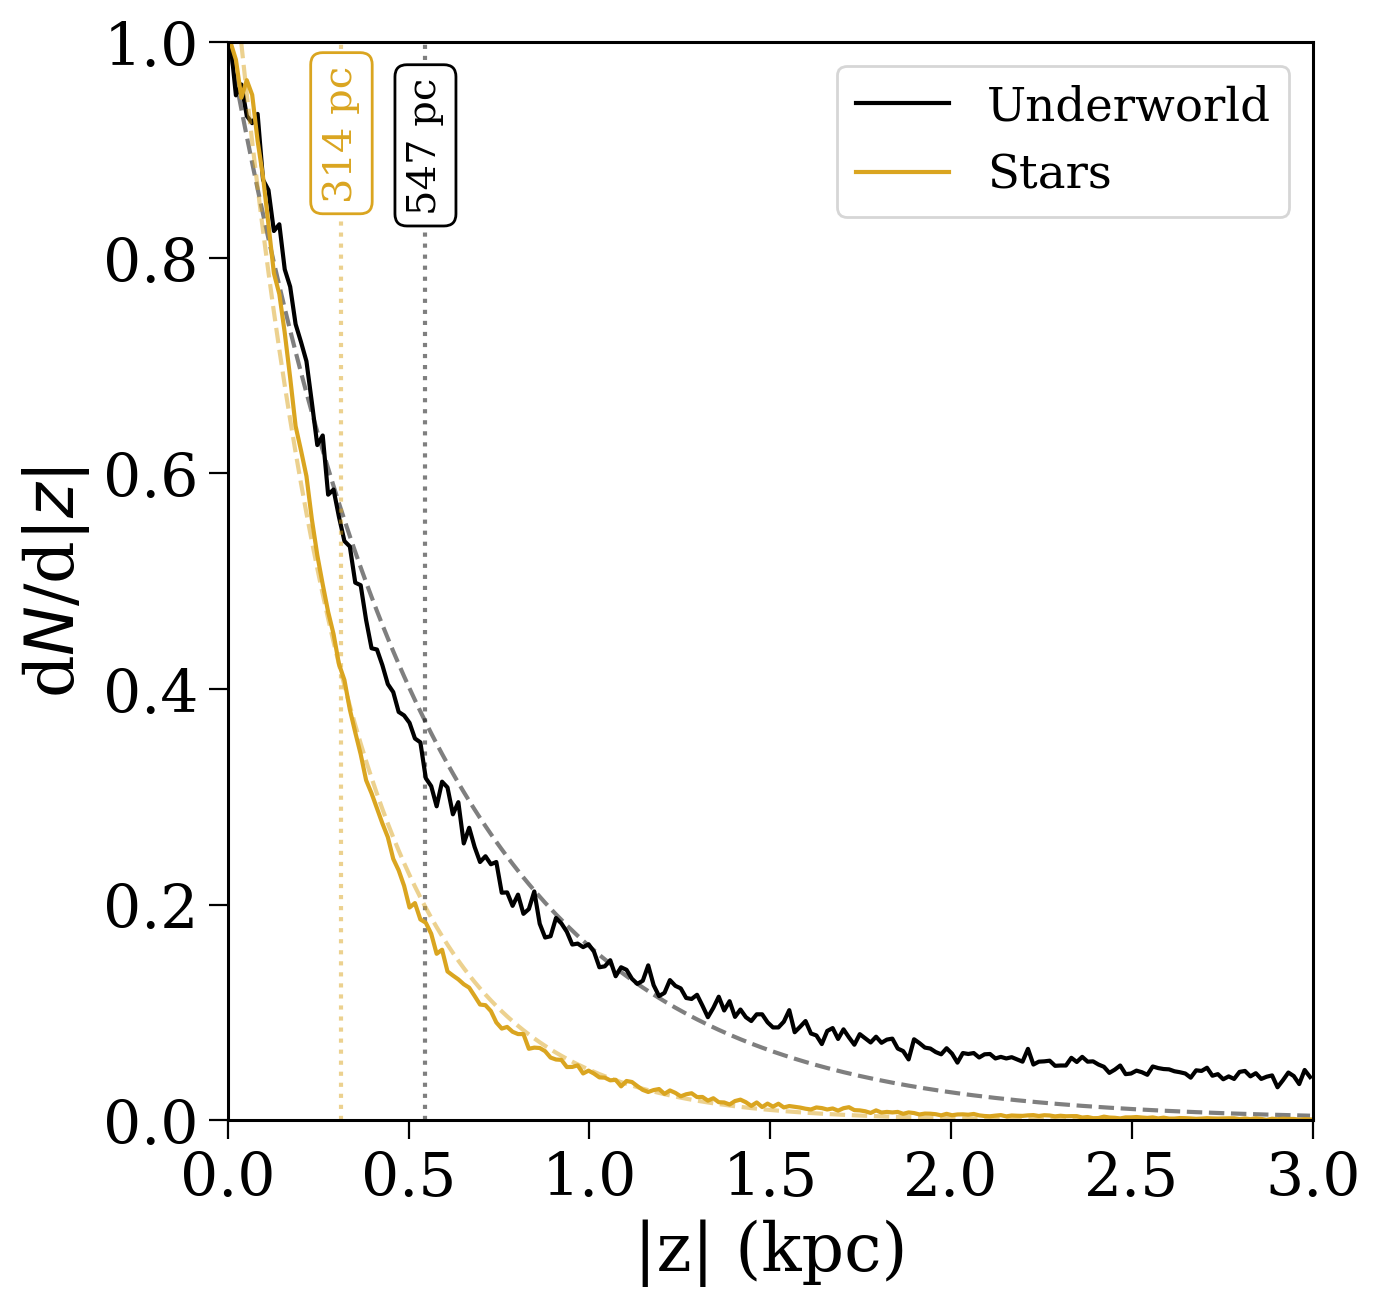

In [56]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour in zip(
    [kinematics["Fiducial"]["pos"]["CO"][:, 2], stars.z],
    ["Underworld", "Stars"],
    ["black", "goldenrod"]
):
    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(0, 3),
        ylim=(0, 1)
    )

# plt.savefig("../plots/scale_height_underworld_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

1.1416343724465612
0.3439501895170205


0.31428988016767323


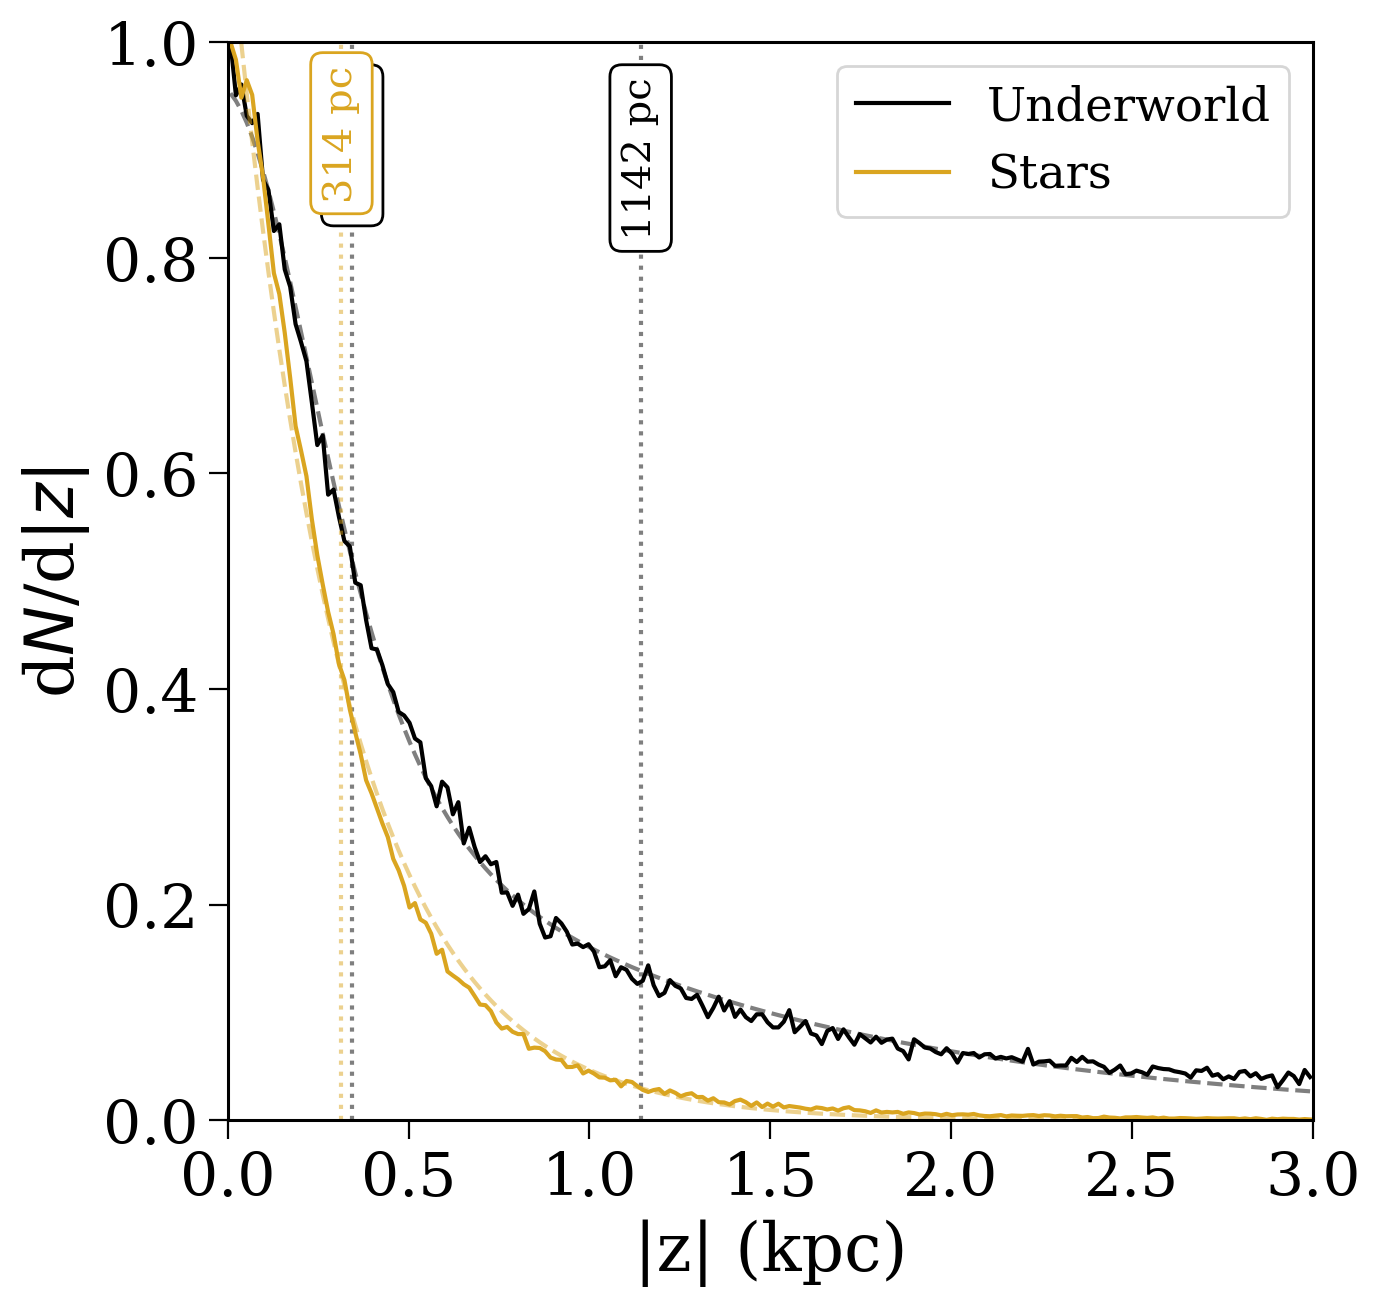

In [57]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour in zip(
    [kinematics["Fiducial"]["pos"]["CO"][:, 2], stars.z],
    ["Underworld", "Stars"],
    ["black", "goldenrod"]
):
    # print(np.percentile(abs(kinematics["Fiducial"]["pos"]["CO"][:, 2])[~kinematics["Fiducial"]["escaped"]["CO"]], [50, 75, 90, 95, 99]))
    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2 if label == "Underworld" else 1
    )

# plt.savefig("../plots/scale_height_underworld_vs_stars.pdf", format="pdf", bbox_inches='tight')
plt.show()

1.1416343724465612
0.3439501895170205


0.9457360343101483
0.3726192508747148
1.258790893381087
0.3291042142463982
0.31428988016767323


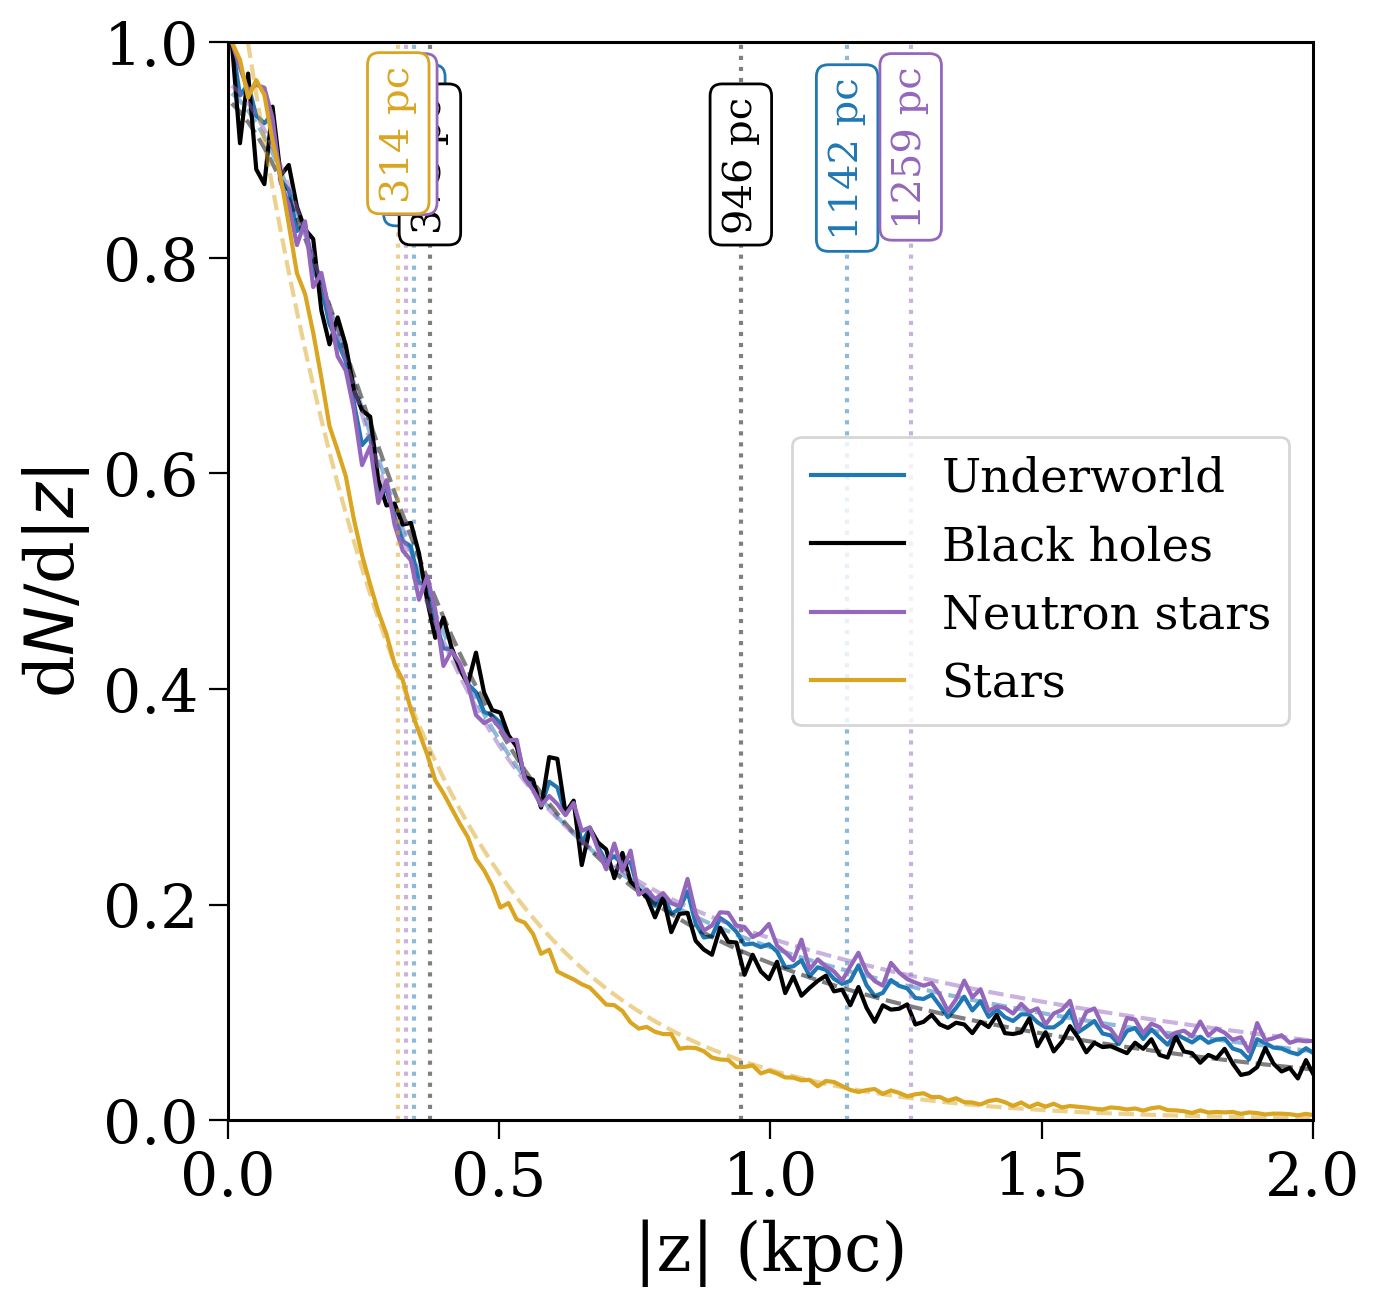

In [58]:
fig, ax = plt.subplots(figsize=(7, 7))

reload(plotting)

for z, label, colour in zip(
    [kinematics["Fiducial"]["pos"]["CO"][:, 2], kinematics["Fiducial"]["pos"]["BH"][:, 2], kinematics["Fiducial"]["pos"]["NS"][:, 2], stars.z],
    ["Underworld", "Black holes", "Neutron stars", "Stars"],
    ["tab:blue", "black", "tab:purple", "goldenrod"]
):
    scale_height, _, _ = plotting.estimate_scale_height(
        z=z,
        plot=True,
        label=label,
        colour=colour,
        show=False,
        fig=fig,
        ax=ax,
        xlim=(0, 2),
        ylim=(0, 1),
        n_components=1 if label == "Stars" else 2
    )

plt.show()

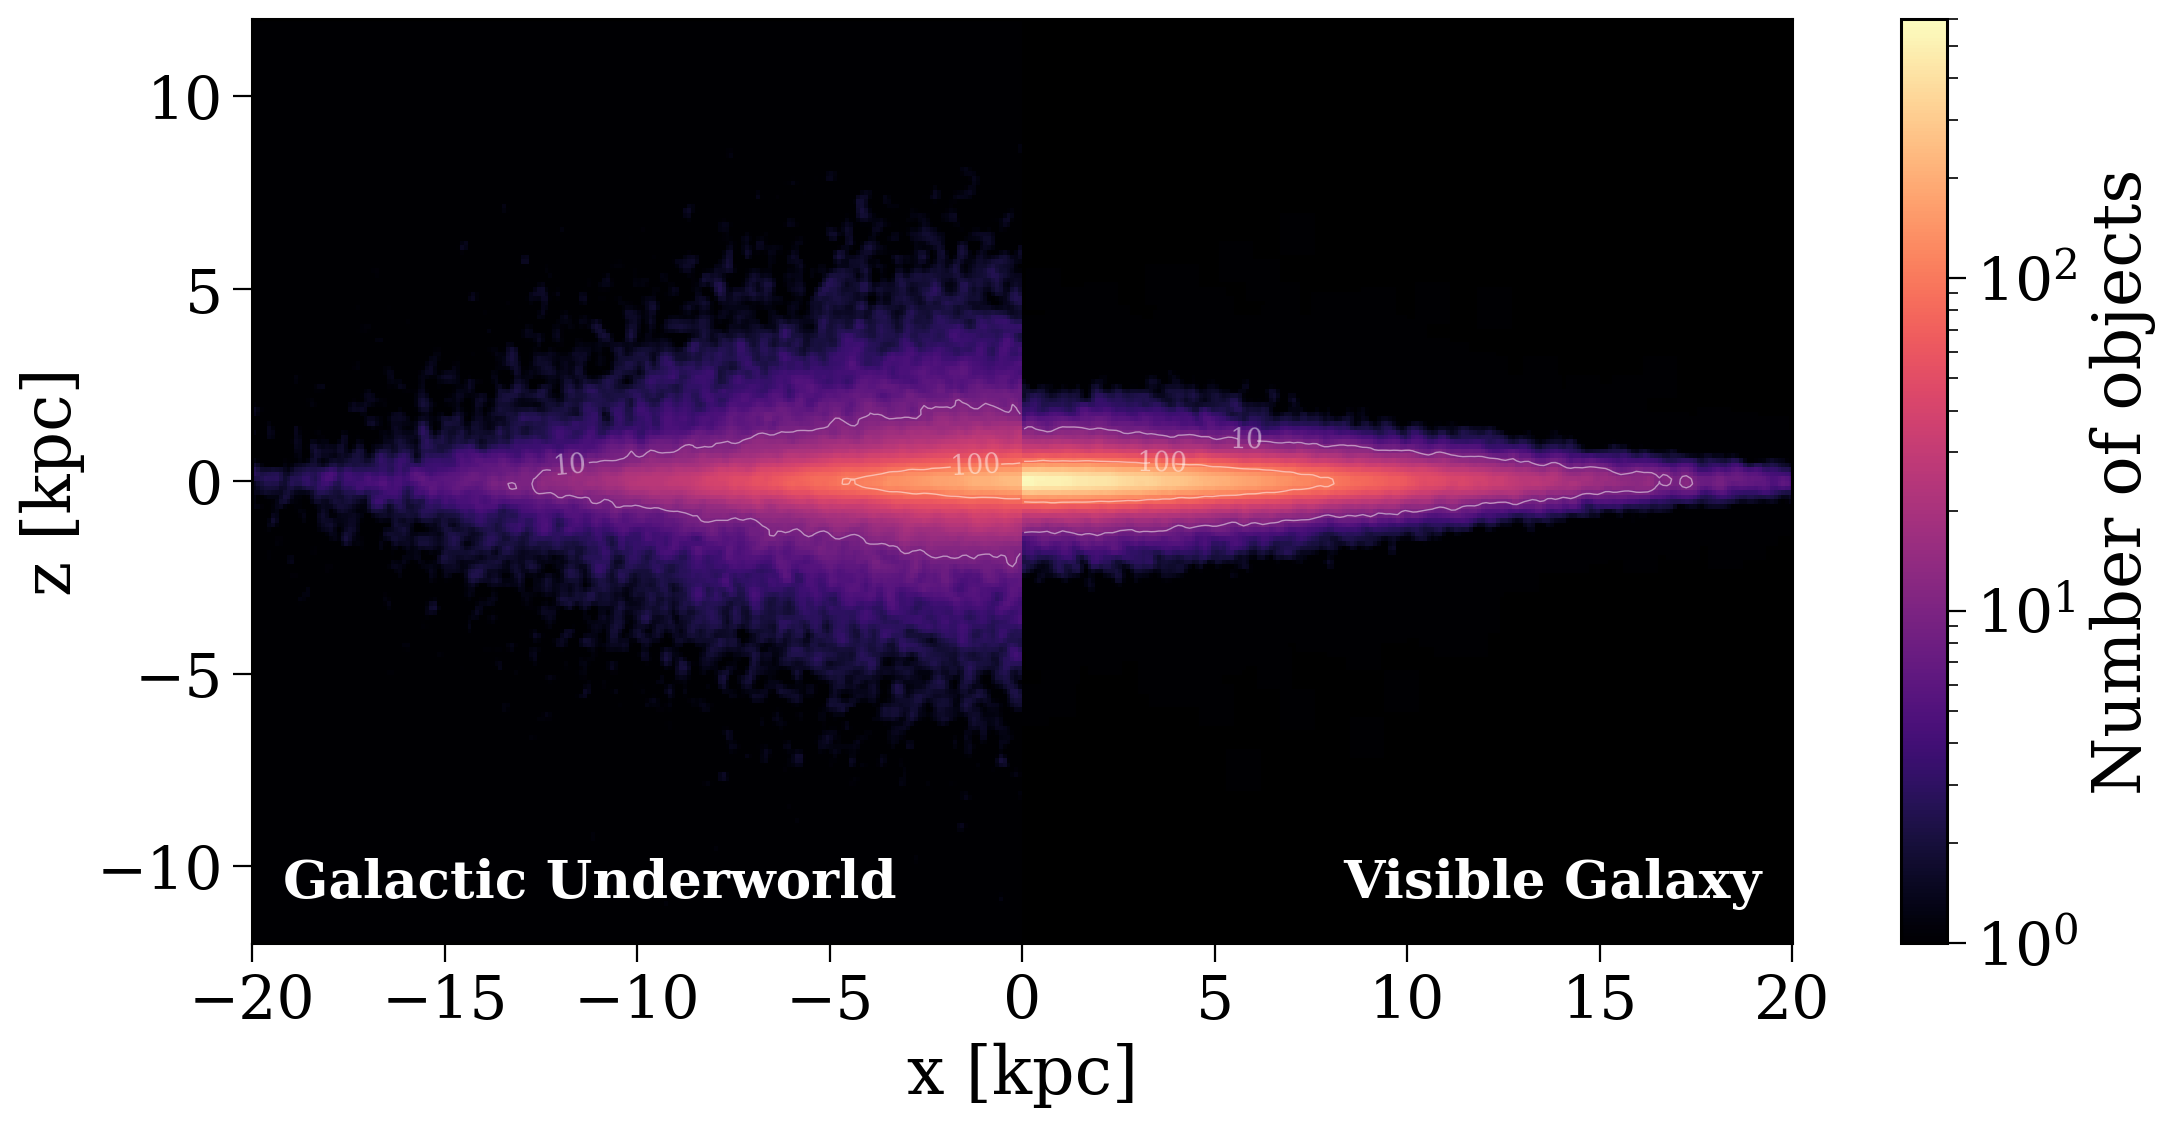

In [59]:
reload(plotting)
fig, ax = plotting.plot_side_on_density(
    xs=[stars.x, kinematics["Fiducial"]["pos"]["CO"][:, 0]],
    zs=[stars.z, kinematics["Fiducial"]["pos"]["CO"][:, 2]],
    labels=["Galactic Underworld", "Visible Galaxy"],
    xlim=20,
    zlim=12,
    n_bins=200,
    sigma=1.0,
    contours=[10, 100],
    apply_smoothing=True,
    show=False
)

plt.savefig("../plots/density_stars_vs_underworld.pdf", format="pdf", bbox_inches='tight')
plt.show()

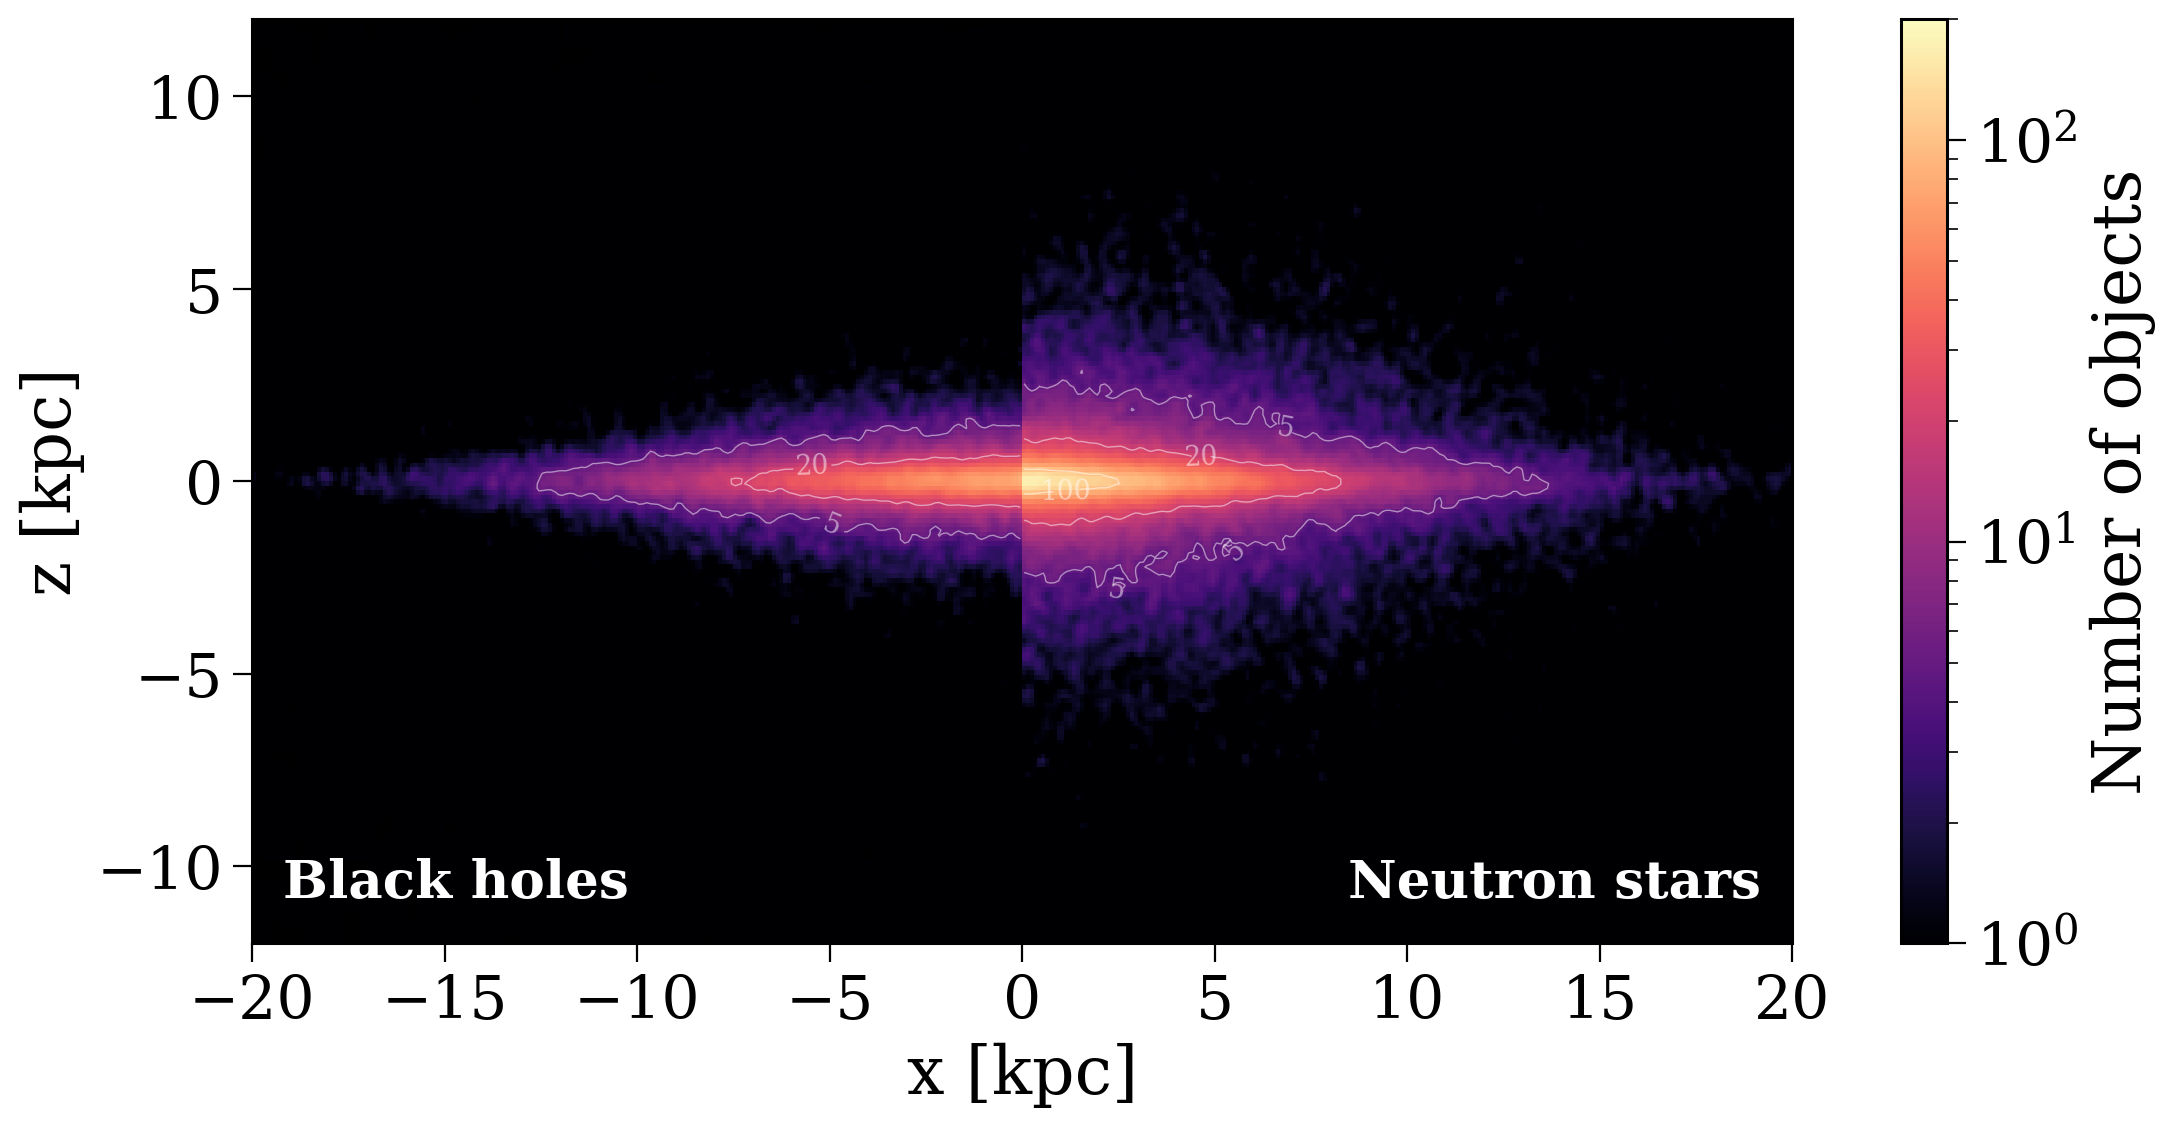

In [60]:
reload(plotting)
plotting.plot_side_on_density(
    xs=[kinematics["Fiducial"]["pos"]["NS"][:, 0], kinematics["Fiducial"]["pos"]["BH"][:, 0]],
    zs=[kinematics["Fiducial"]["pos"]["NS"][:, 2], kinematics["Fiducial"]["pos"]["BH"][:, 2]],
    labels=["Black holes", "Neutron stars"],
    xlim=20,
    zlim=12,
    n_bins=200,
    sigma=1.0,
    contours=[5, 20, 100],
    apply_smoothing=True,
    show=False
)

plt.savefig("../plots/density_bh_vs_ns.pdf", format="pdf", bbox_inches='tight')
plt.show()

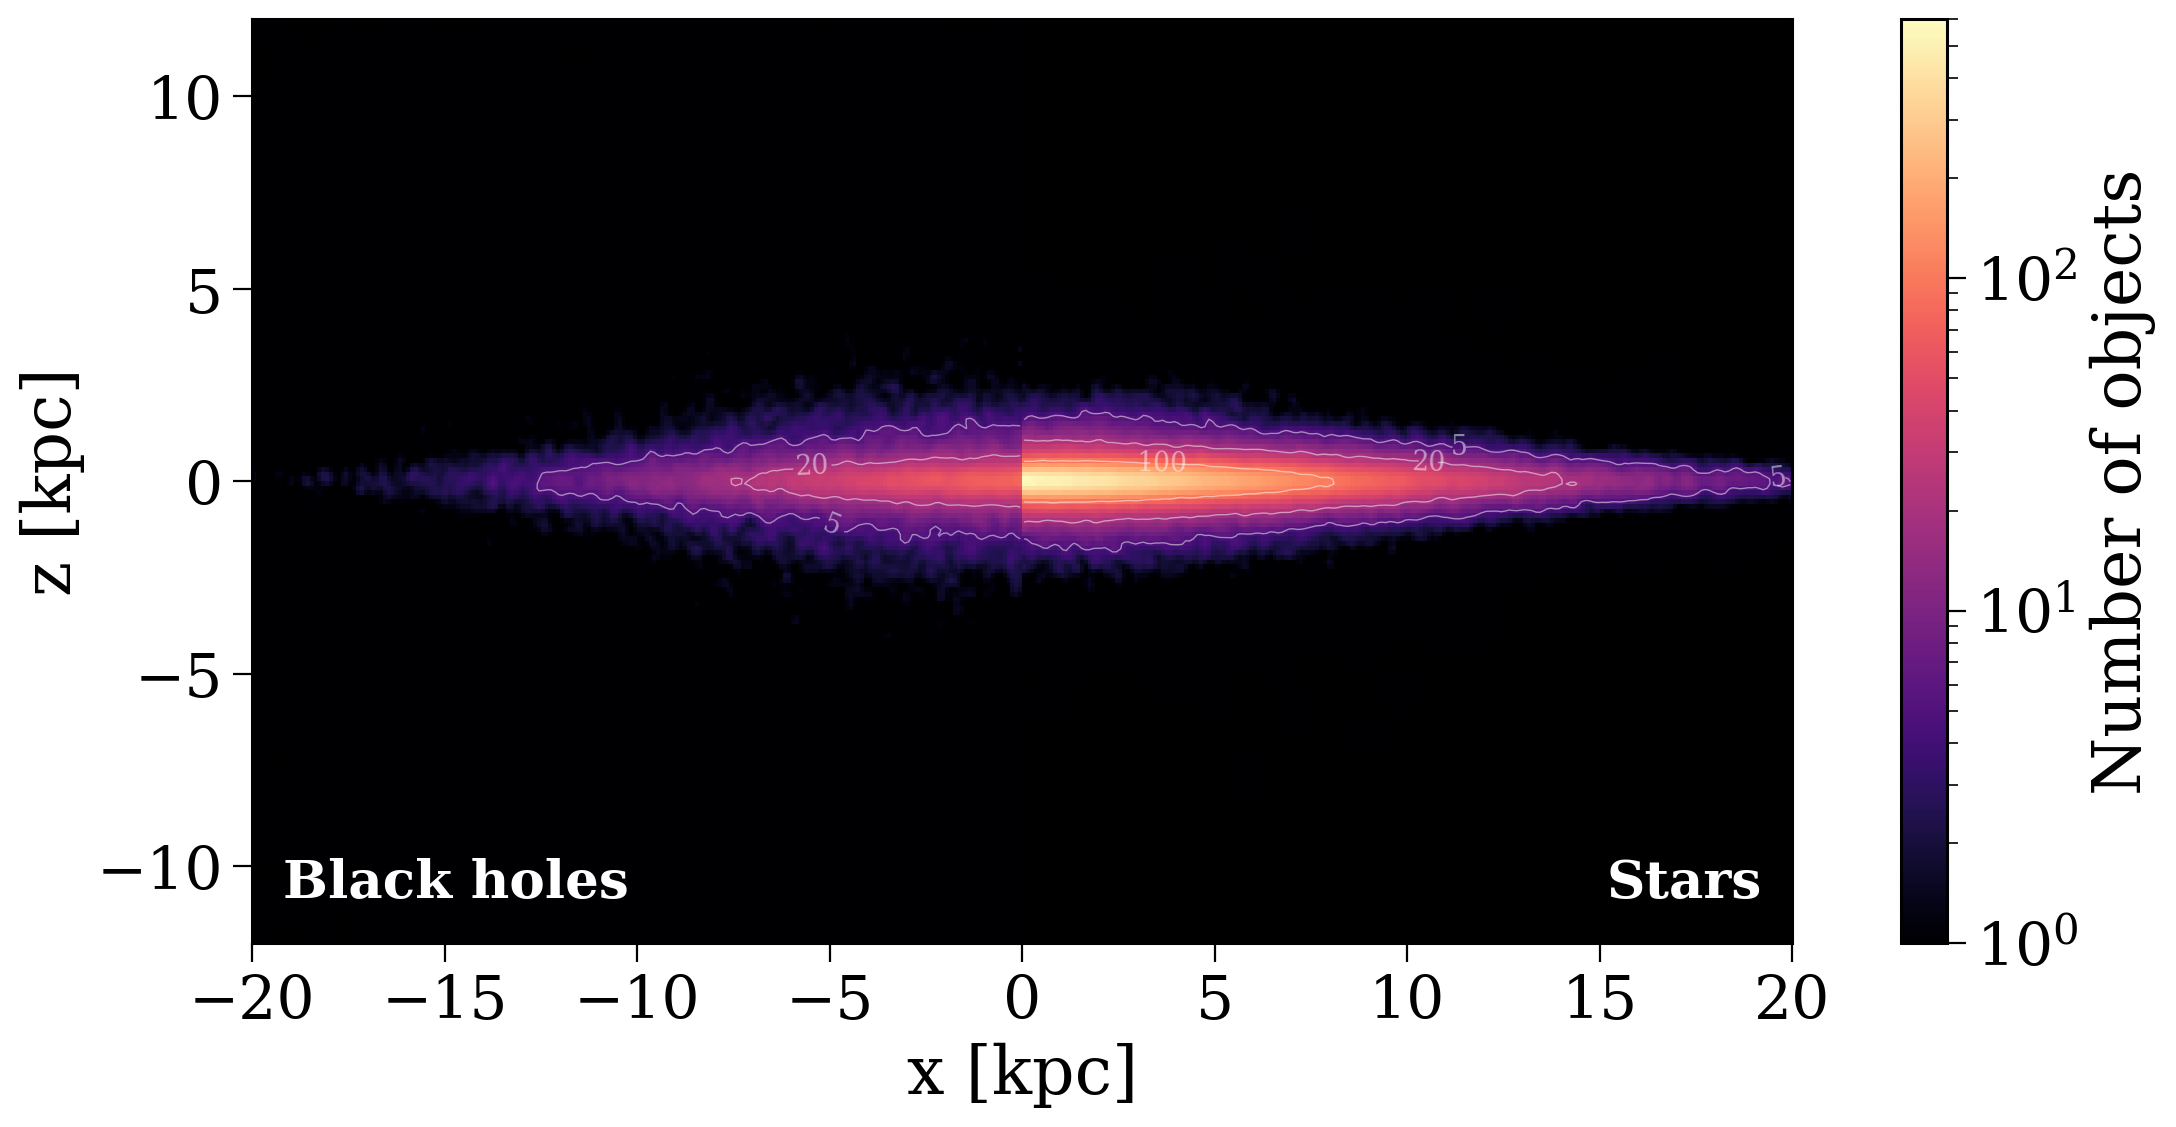

In [61]:
reload(plotting)
plotting.plot_side_on_density(
    xs=[stars.x, kinematics["Fiducial"]["pos"]["BH"][:, 0]],
    zs=[stars.z, kinematics["Fiducial"]["pos"]["BH"][:, 2]],
    labels=["Black holes", "Stars"],
    xlim=20,
    zlim=12,
    n_bins=200,
    sigma=1.0,
    contours=[5, 20, 100],
    apply_smoothing=True,
    show=False
)

plt.show()

# Mass distributions

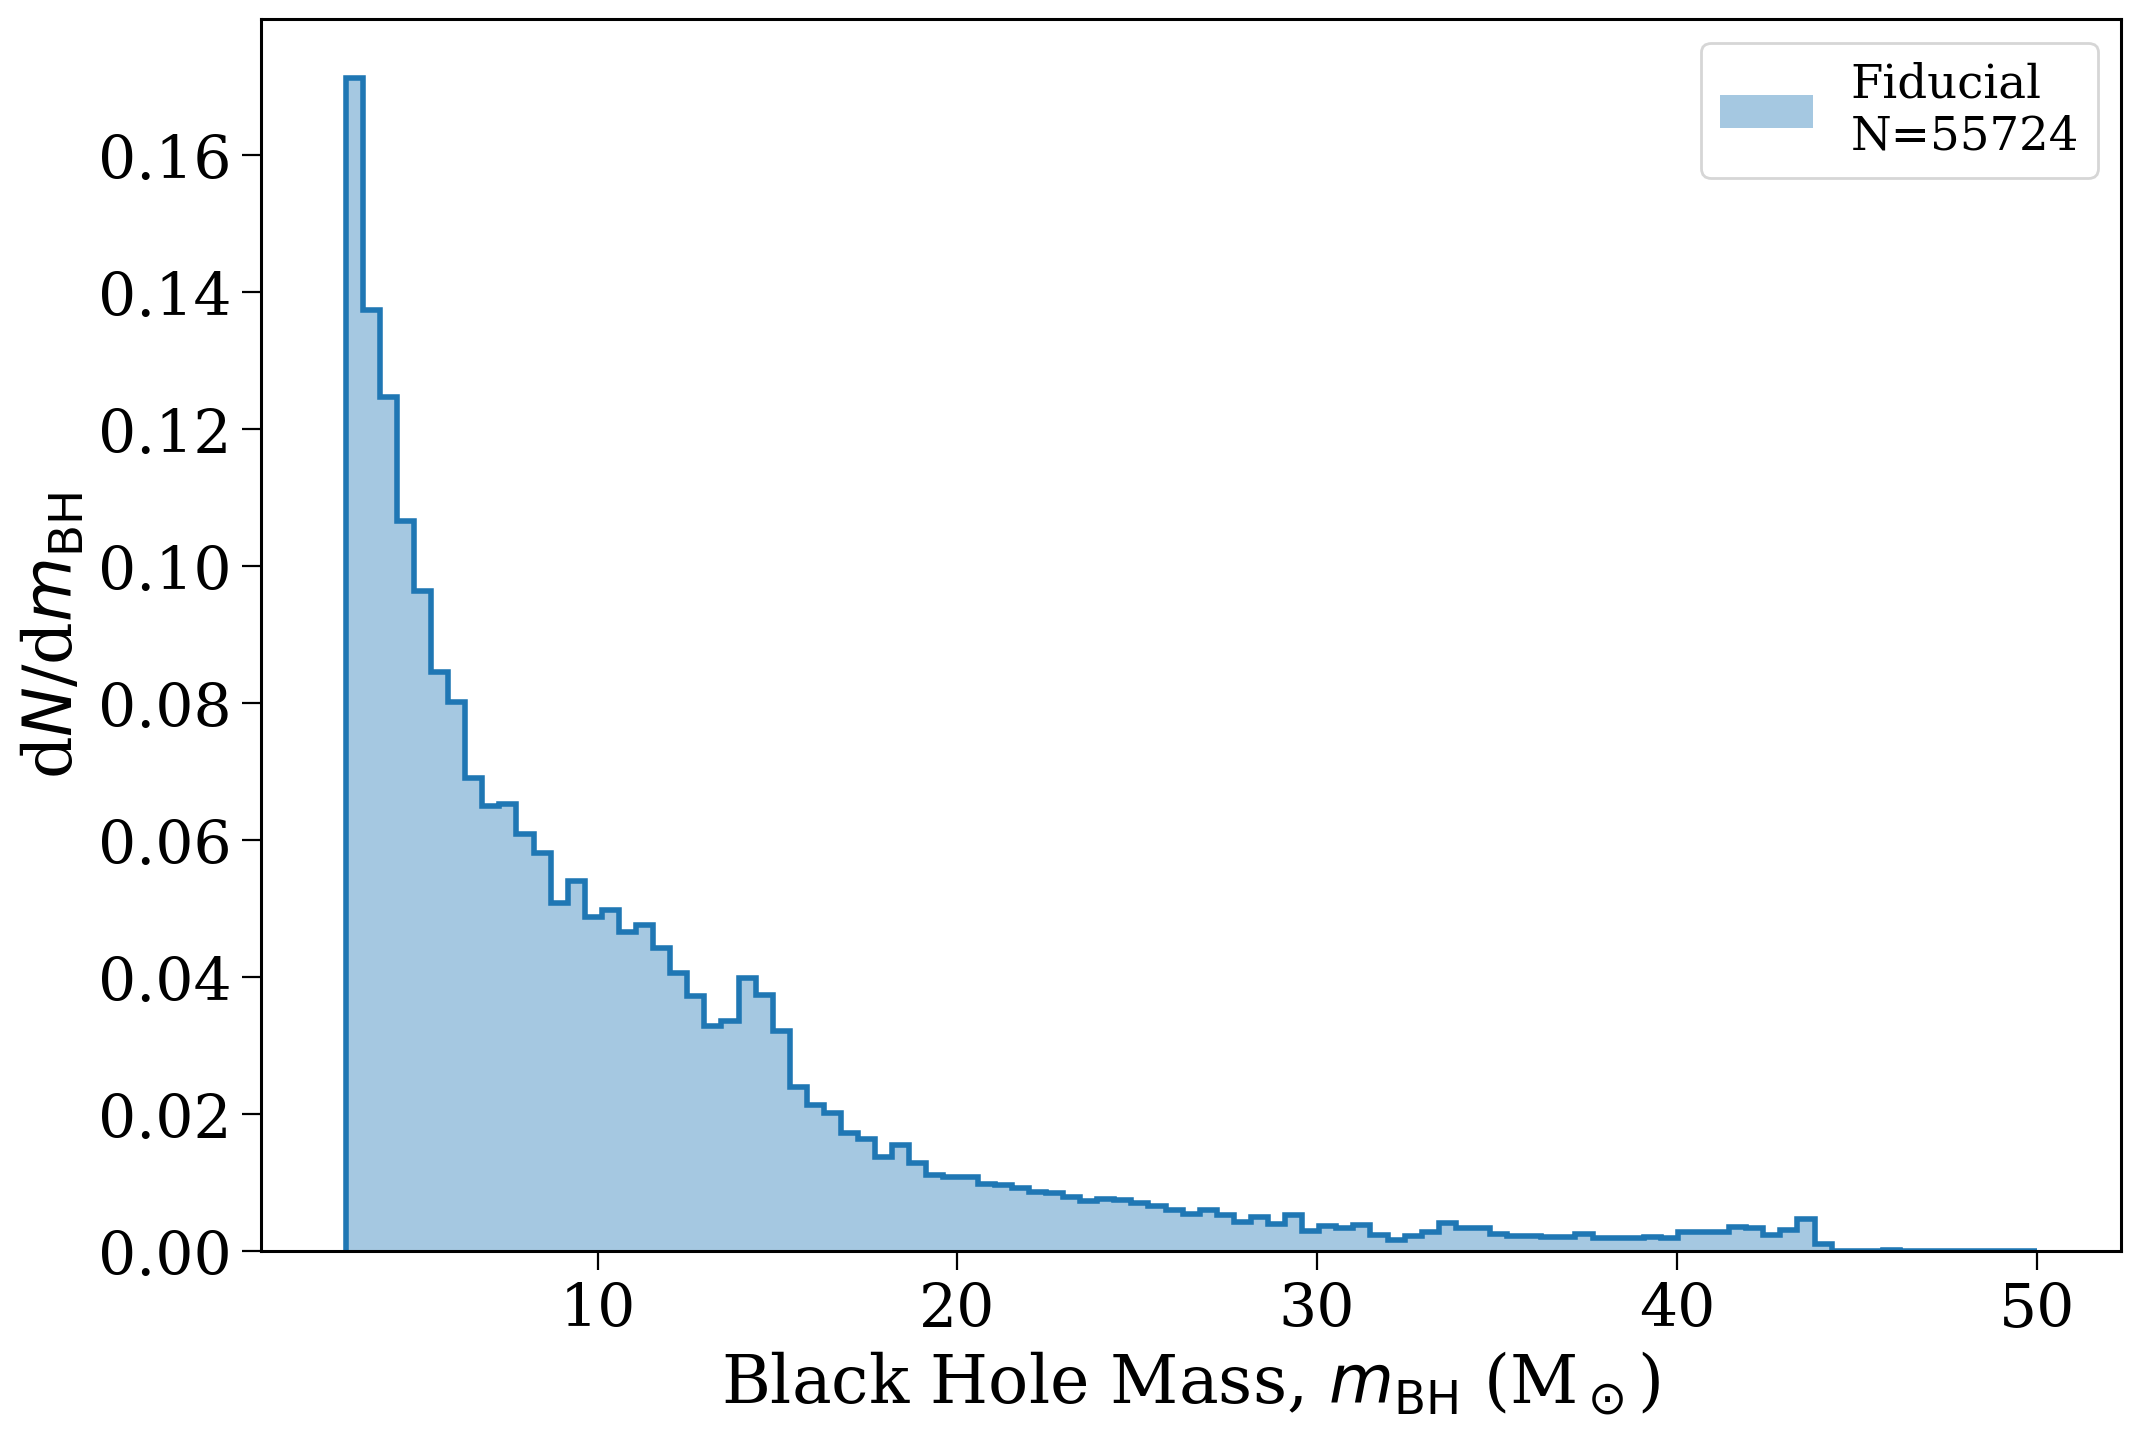

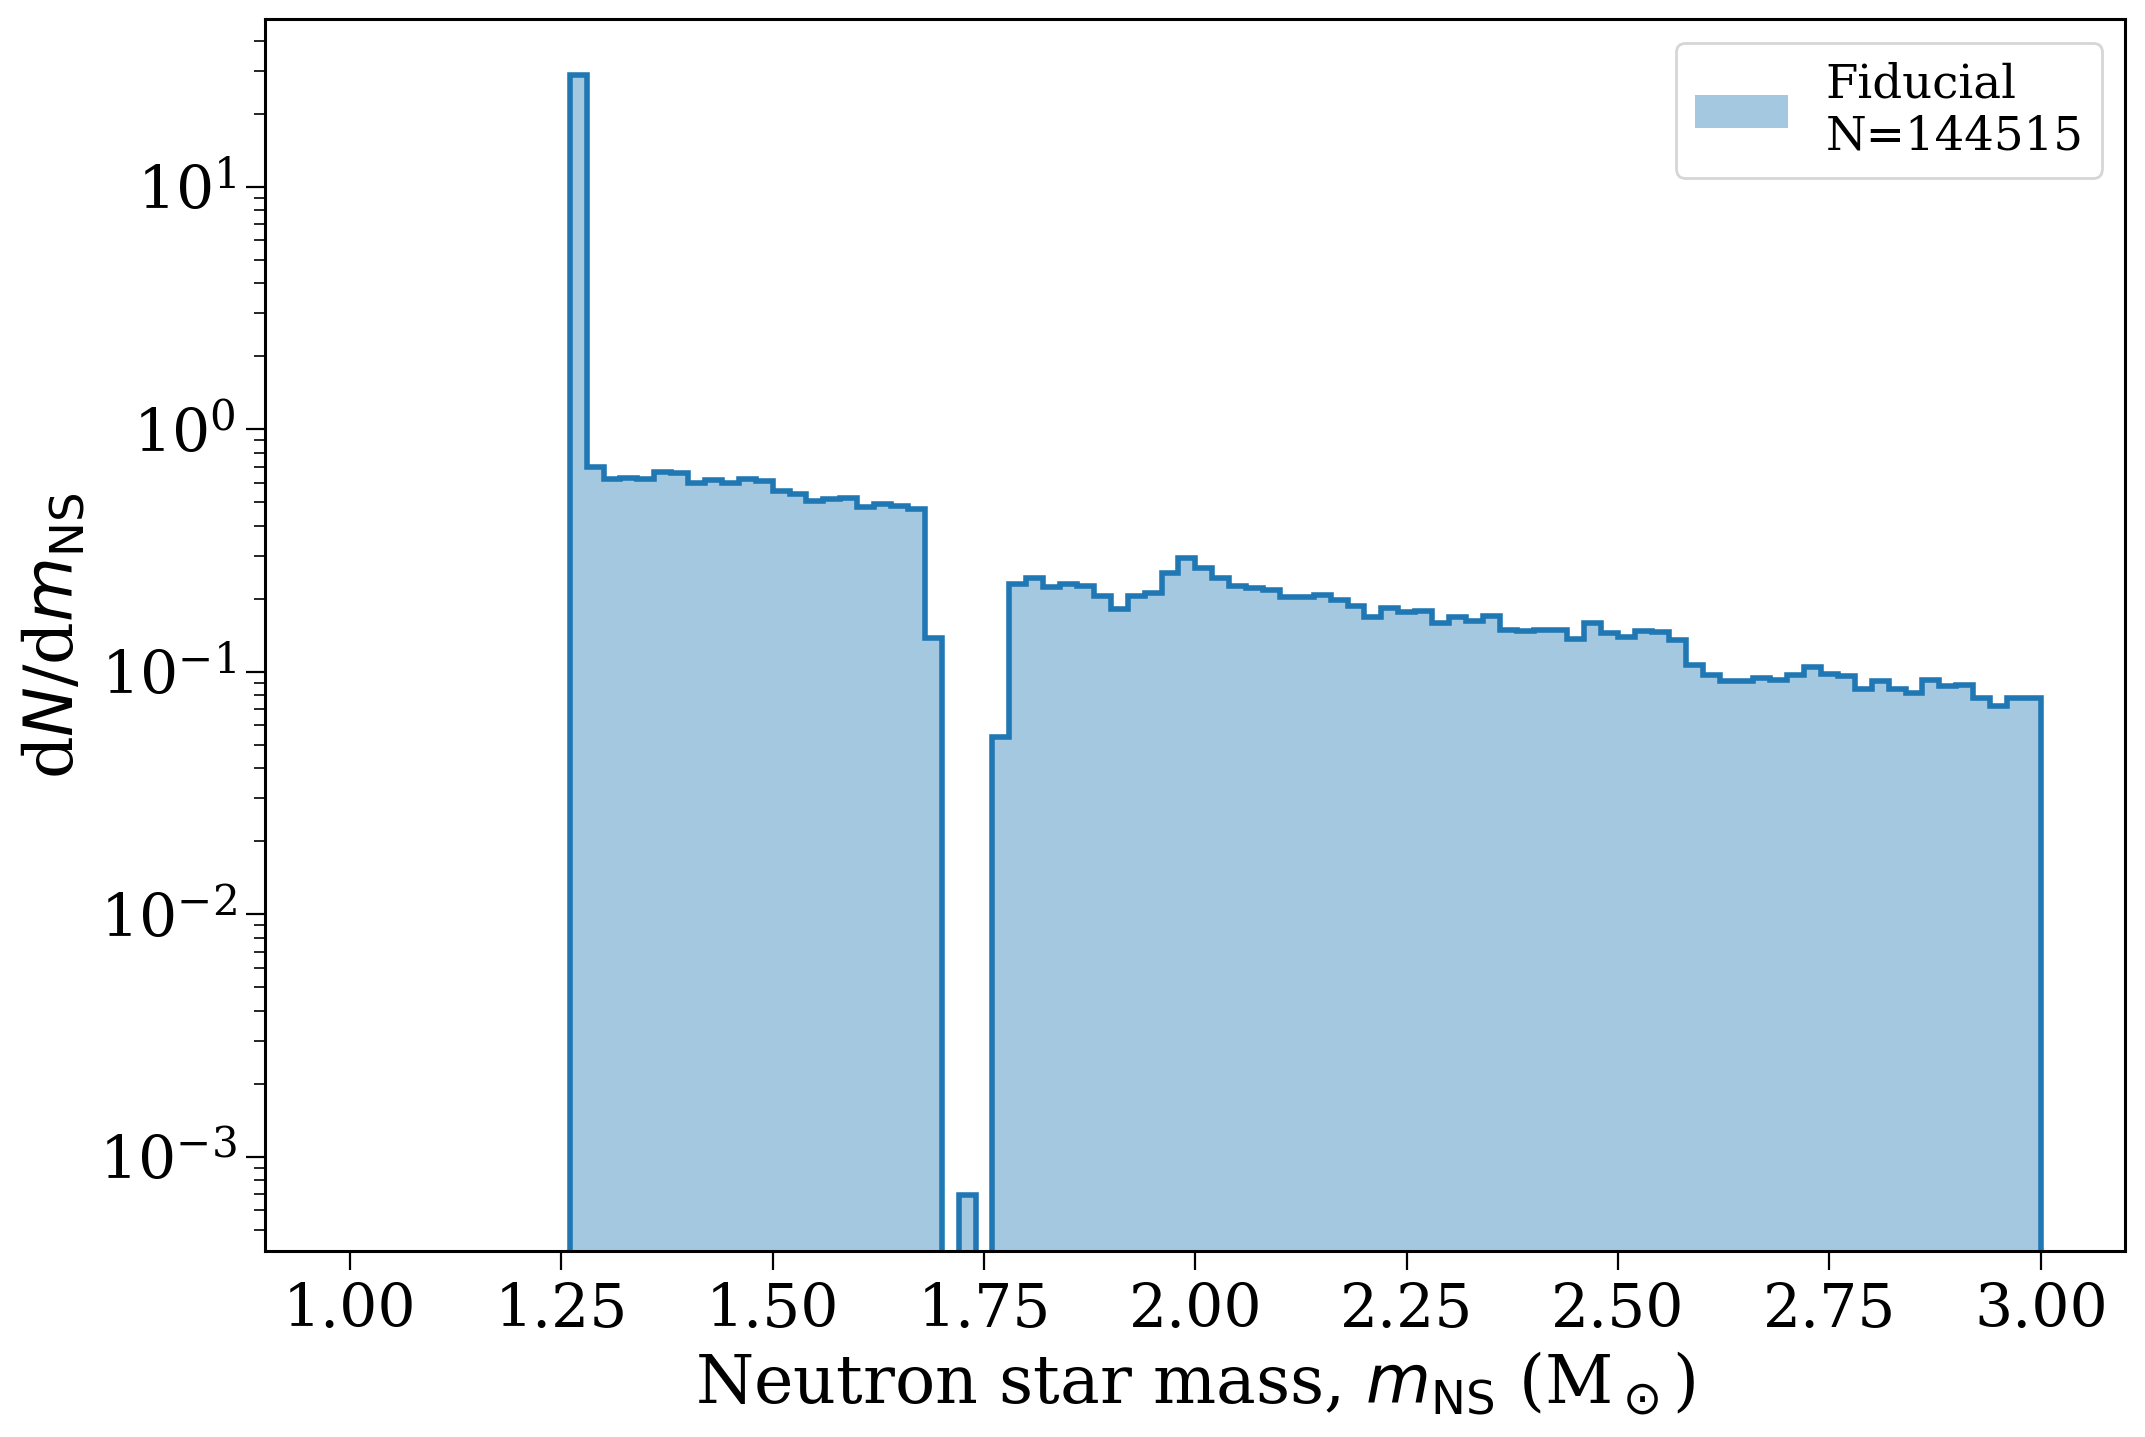

(<Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='Neutron star mass, $m_{\\rm NS}$ (M$_\\odot$)', ylabel='d$N$/d$m_{\\rm NS}$'>)

In [62]:
fig, ax = plotting.compare_table_quantity(
    pops=[pop],
    quantity="mass",
    kstar=14,
    bins=np.linspace(3, 50, 100),
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm BH}$",
    show=False
)
plt.savefig("../plots/bh_mass_distribution.pdf", format="pdf", bbox_inches='tight')
plt.show()

plotting.compare_table_quantity(
    pops=[pop],
    quantity="mass",
    kstar=13,
    bins=np.linspace(1, 3, 101),
    xlabel=r"Neutron star mass, $m_{\rm NS}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm NS}$",
    yscale='log'
)

# Spatial vs. Mass

Larger mass objects (particularly BHs) are going to get different kicks, we should see that show up in their distribution

In [63]:
masses = {
    "BH": np.concatenate((
        pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
        pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
    )),
    "NS": np.concatenate((
        pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
        pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
    )),
}
masses["CO"] = np.concatenate((masses["NS"], masses["BH"]))

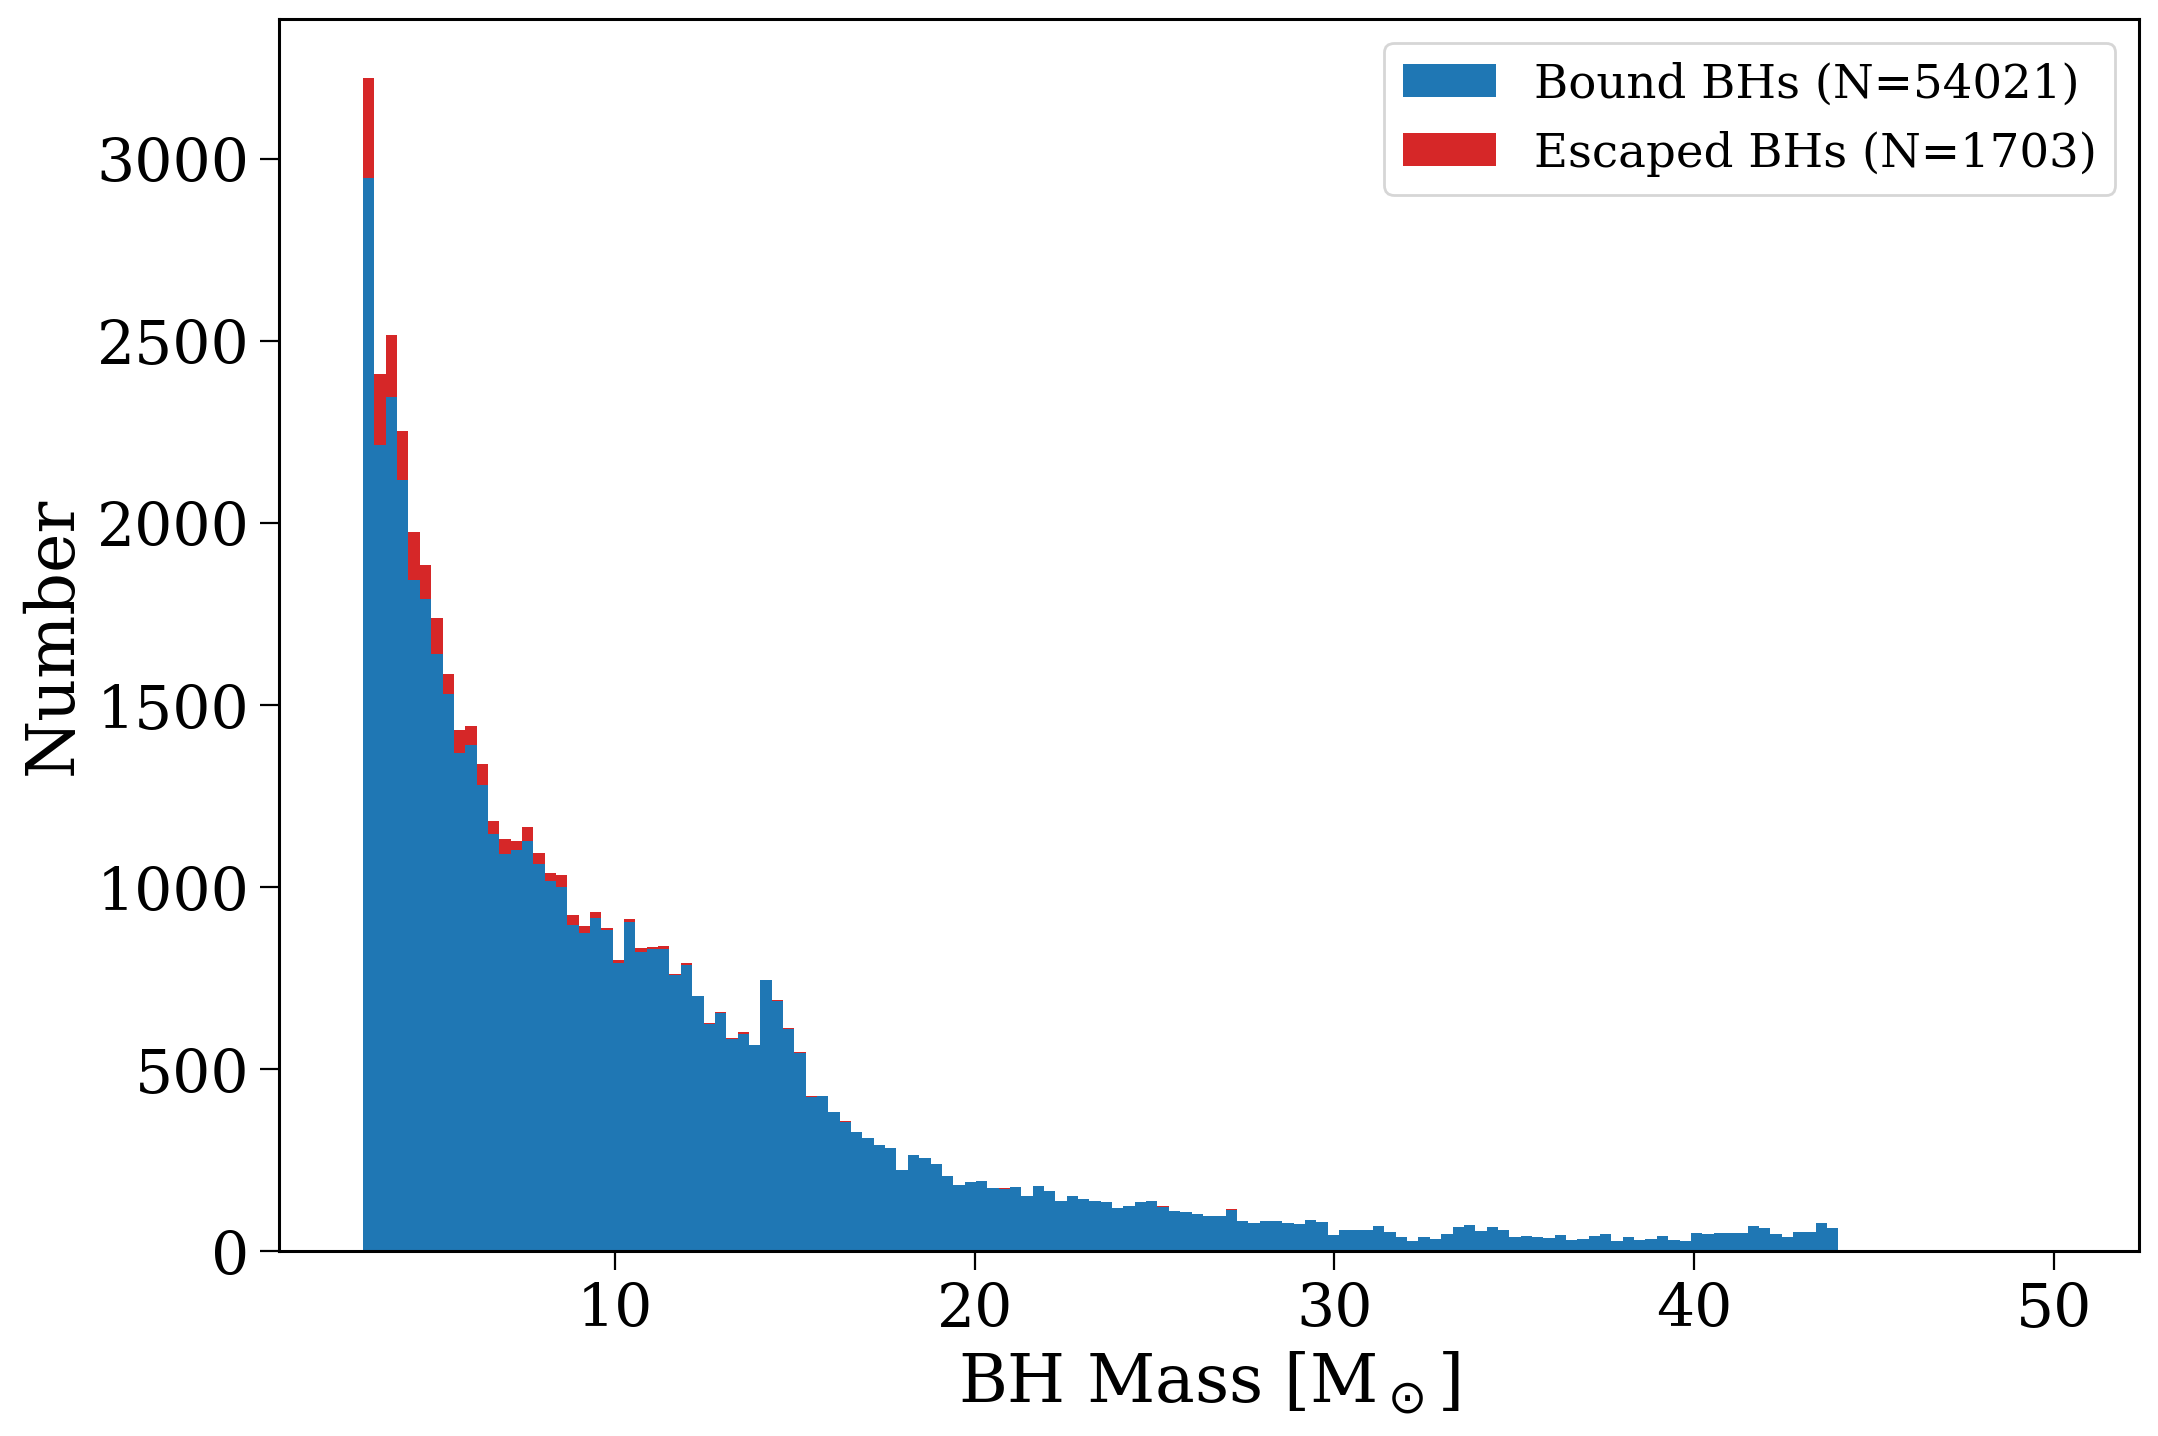

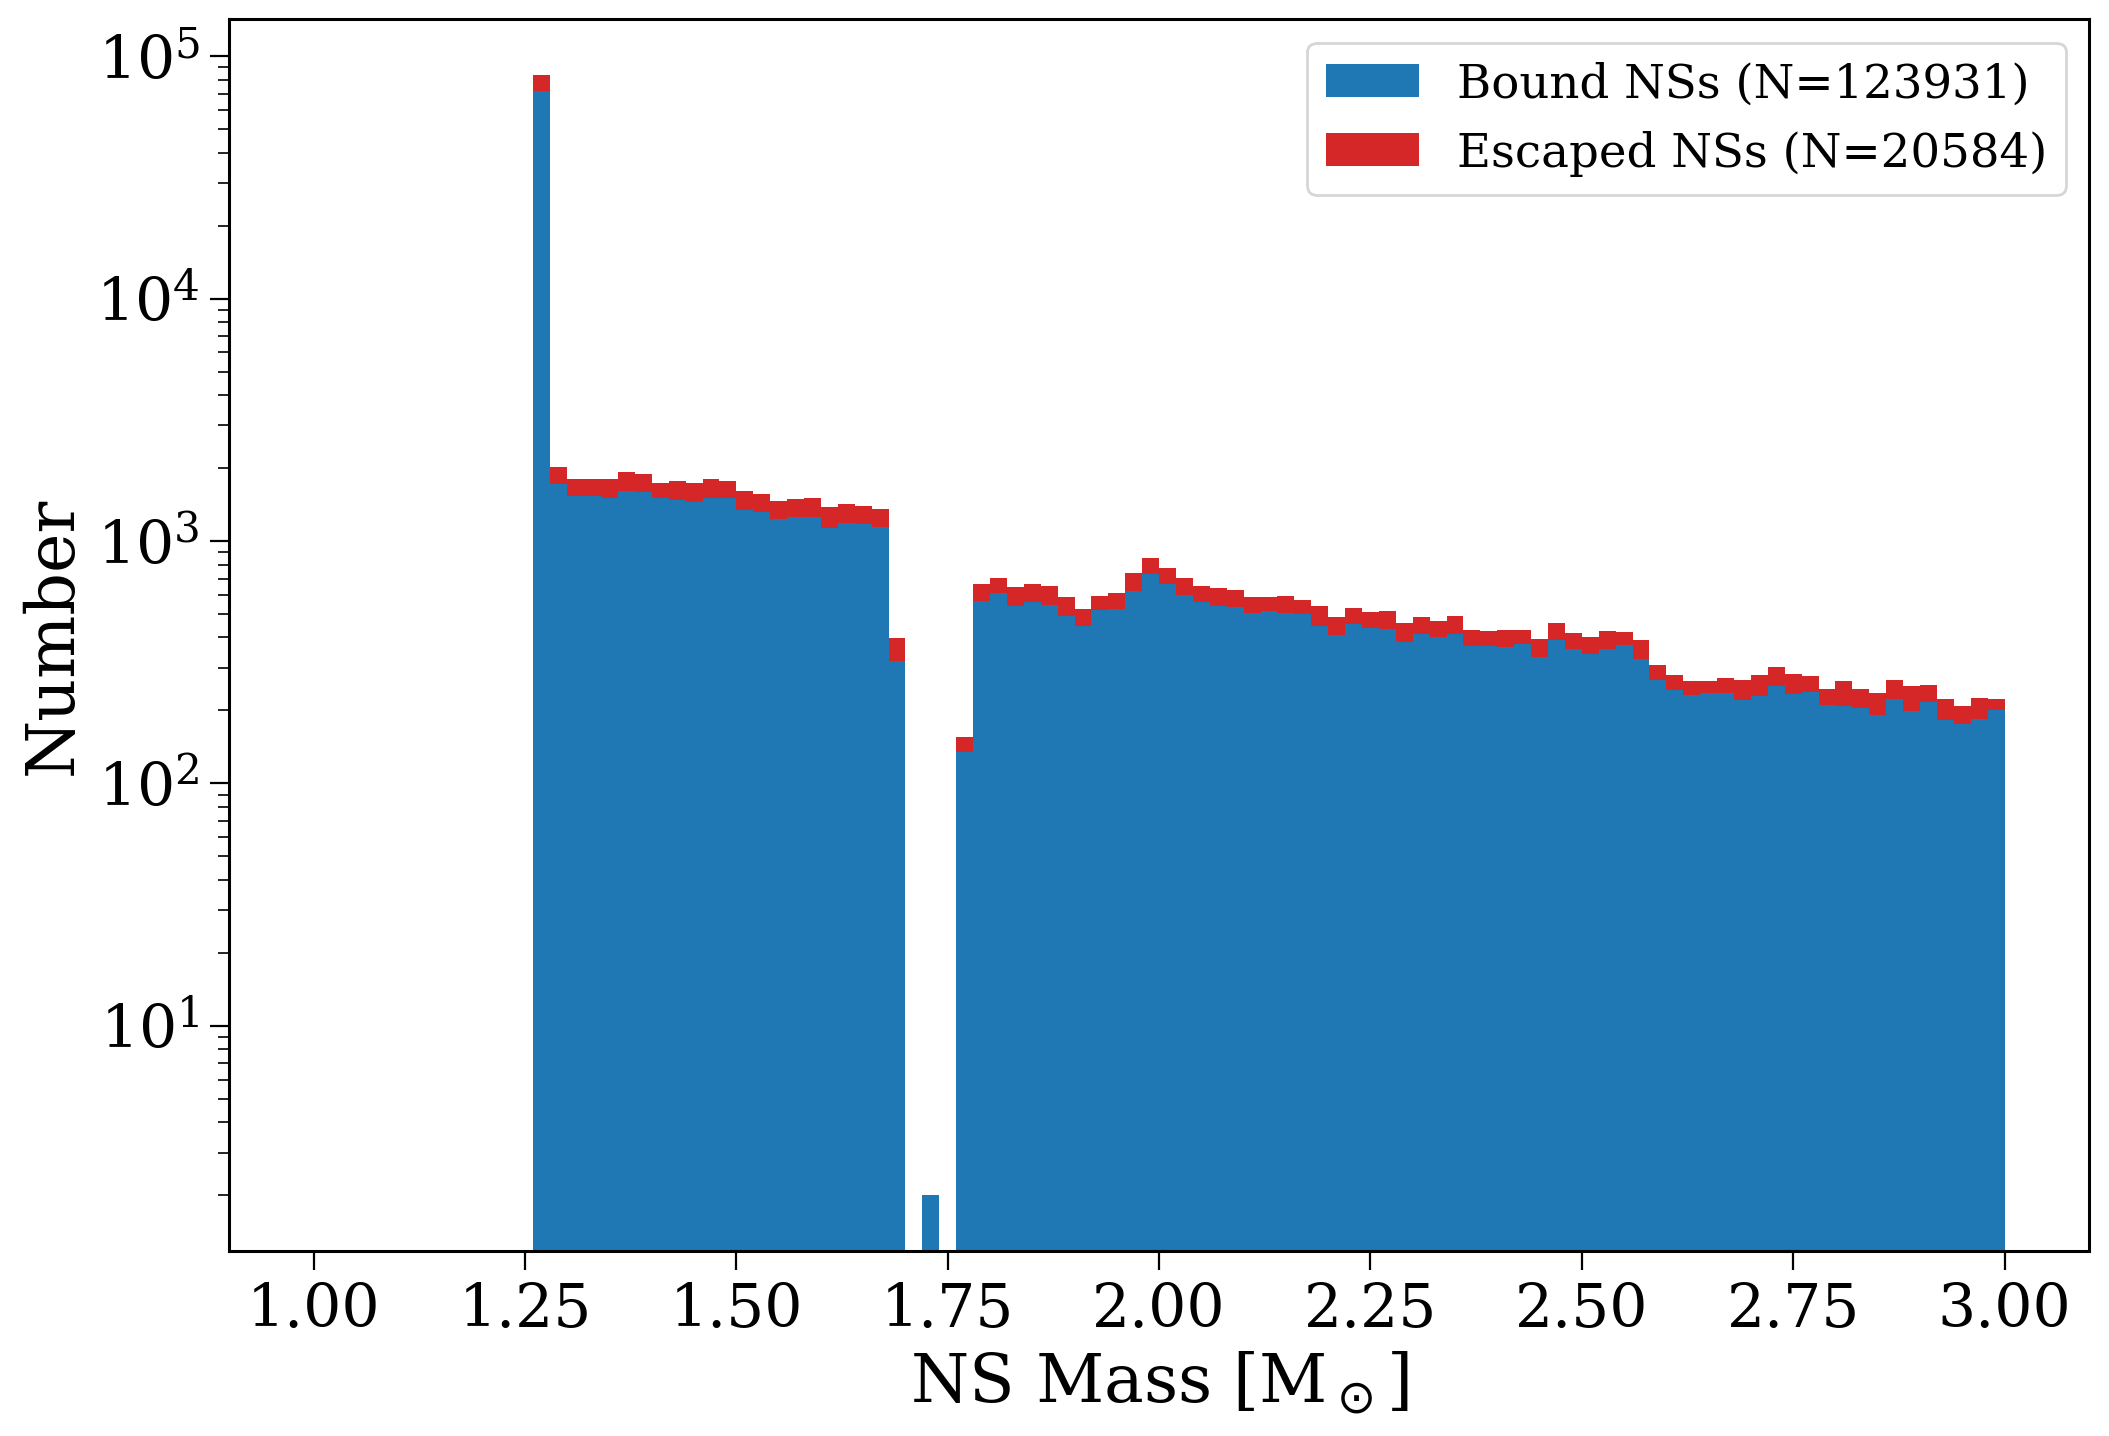

In [64]:
kinematics[pop.label]["escaped"] = {}
for co_type, bins in zip(["CO", "BH", "NS"], [None, np.linspace(3, 50, 150), np.linspace(1, 3, 101)]):

    pos = kinematics[pop.label]["pos"][co_type]
    vel = kinematics[pop.label]["vel"][co_type]

    V = np.linalg.norm(vel.to(u.km/u.s).value, axis=1)

    escaped = V >= np.sqrt(-2 * pop.galactic_potential(pos.T)).to(u.km / u.s).value

    kinematics[pop.label]["escaped"][co_type] = escaped

    if co_type == "CO":
        continue

    fig, ax = plt.subplots()

    stacked_data = [masses[co_type][~escaped], masses[co_type][escaped]]
    ax.hist(
        stacked_data,
        bins=bins,
        color=["tab:blue", "tab:red"],
        label=[f'Bound {co_type}s (N={np.sum(~escaped)})', f'Escaped {co_type}s (N={np.sum(escaped)})'],
        stacked=True,
    )

    plt.legend()

    ax.set(
        xlabel=f'{co_type} Mass [M$_\odot$]',
        ylabel='Number',
        yscale='log' if co_type == "NS" else 'linear',
    )

    plt.show()

## Stats

In [65]:
average_escaped_BH_mass = np.mean(masses["BH"][kinematics[pop.label]["escaped"]["BH"]])
average_bound_BH_mass = np.mean(masses["BH"][~kinematics[pop.label]["escaped"]["BH"]])

In [66]:
avg_bound_BH_close_to_disc = np.mean(masses["BH"][(
    ~kinematics[pop.label]["escaped"]["BH"] &
    (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) < 1)
)])

avg_bound_BH_far_from_disc = np.mean(masses["BH"][(
    ~kinematics[pop.label]["escaped"]["BH"] &
    (abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value) >= 1)
)])

In [67]:
print("Average BH masses:")
print(f"  Escaped: {average_escaped_BH_mass:.1f} Msun")
print(f"  Bound:   {average_bound_BH_mass:.1f} Msun")
print(f"    Close to disc (<1 kpc):  {avg_bound_BH_close_to_disc:.1f} Msun")
print(f"    Far from disc (>=1 kpc): {avg_bound_BH_far_from_disc:.1f} Msun")

Average BH masses:
  Escaped: 5.2 Msun
  Bound:   10.8 Msun
    Close to disc (<1 kpc):  12.1 Msun
    Far from disc (>=1 kpc): 7.9 Msun


In [68]:
# convert the above print statements to a LaTeX table
print("\nLaTeX table:")
print(r"\begin{tabular}{l c}")
print(r"  \hline")
print(r"  Population & Average BH Mass (M$_\odot$) \\")
print(r"  \hline")
print(f"  Escaped & {average_escaped_BH_mass:.1f} \\")
print(f"  Bound & {average_bound_BH_mass:.1f} \\")
print(f"  \quad Close to disc (<1 kpc) & {avg_bound_BH_close_to_disc:.1f} \\")
print(f"  \quad Far from disc (>=1 kpc) & {avg_bound_BH_far_from_disc:.1f} \\")
print(r"  \hline")
print(r"\end{tabular}")


LaTeX table:
\begin{tabular}{l c}
  \hline
  Population & Average BH Mass (M$_\odot$) \\
  \hline
  Escaped & 5.2 \
  Bound & 10.8 \
  \quad Close to disc (<1 kpc) & 12.1 \
  \quad Far from disc (>=1 kpc) & 7.9 \
  \hline
\end{tabular}


# Progenitors

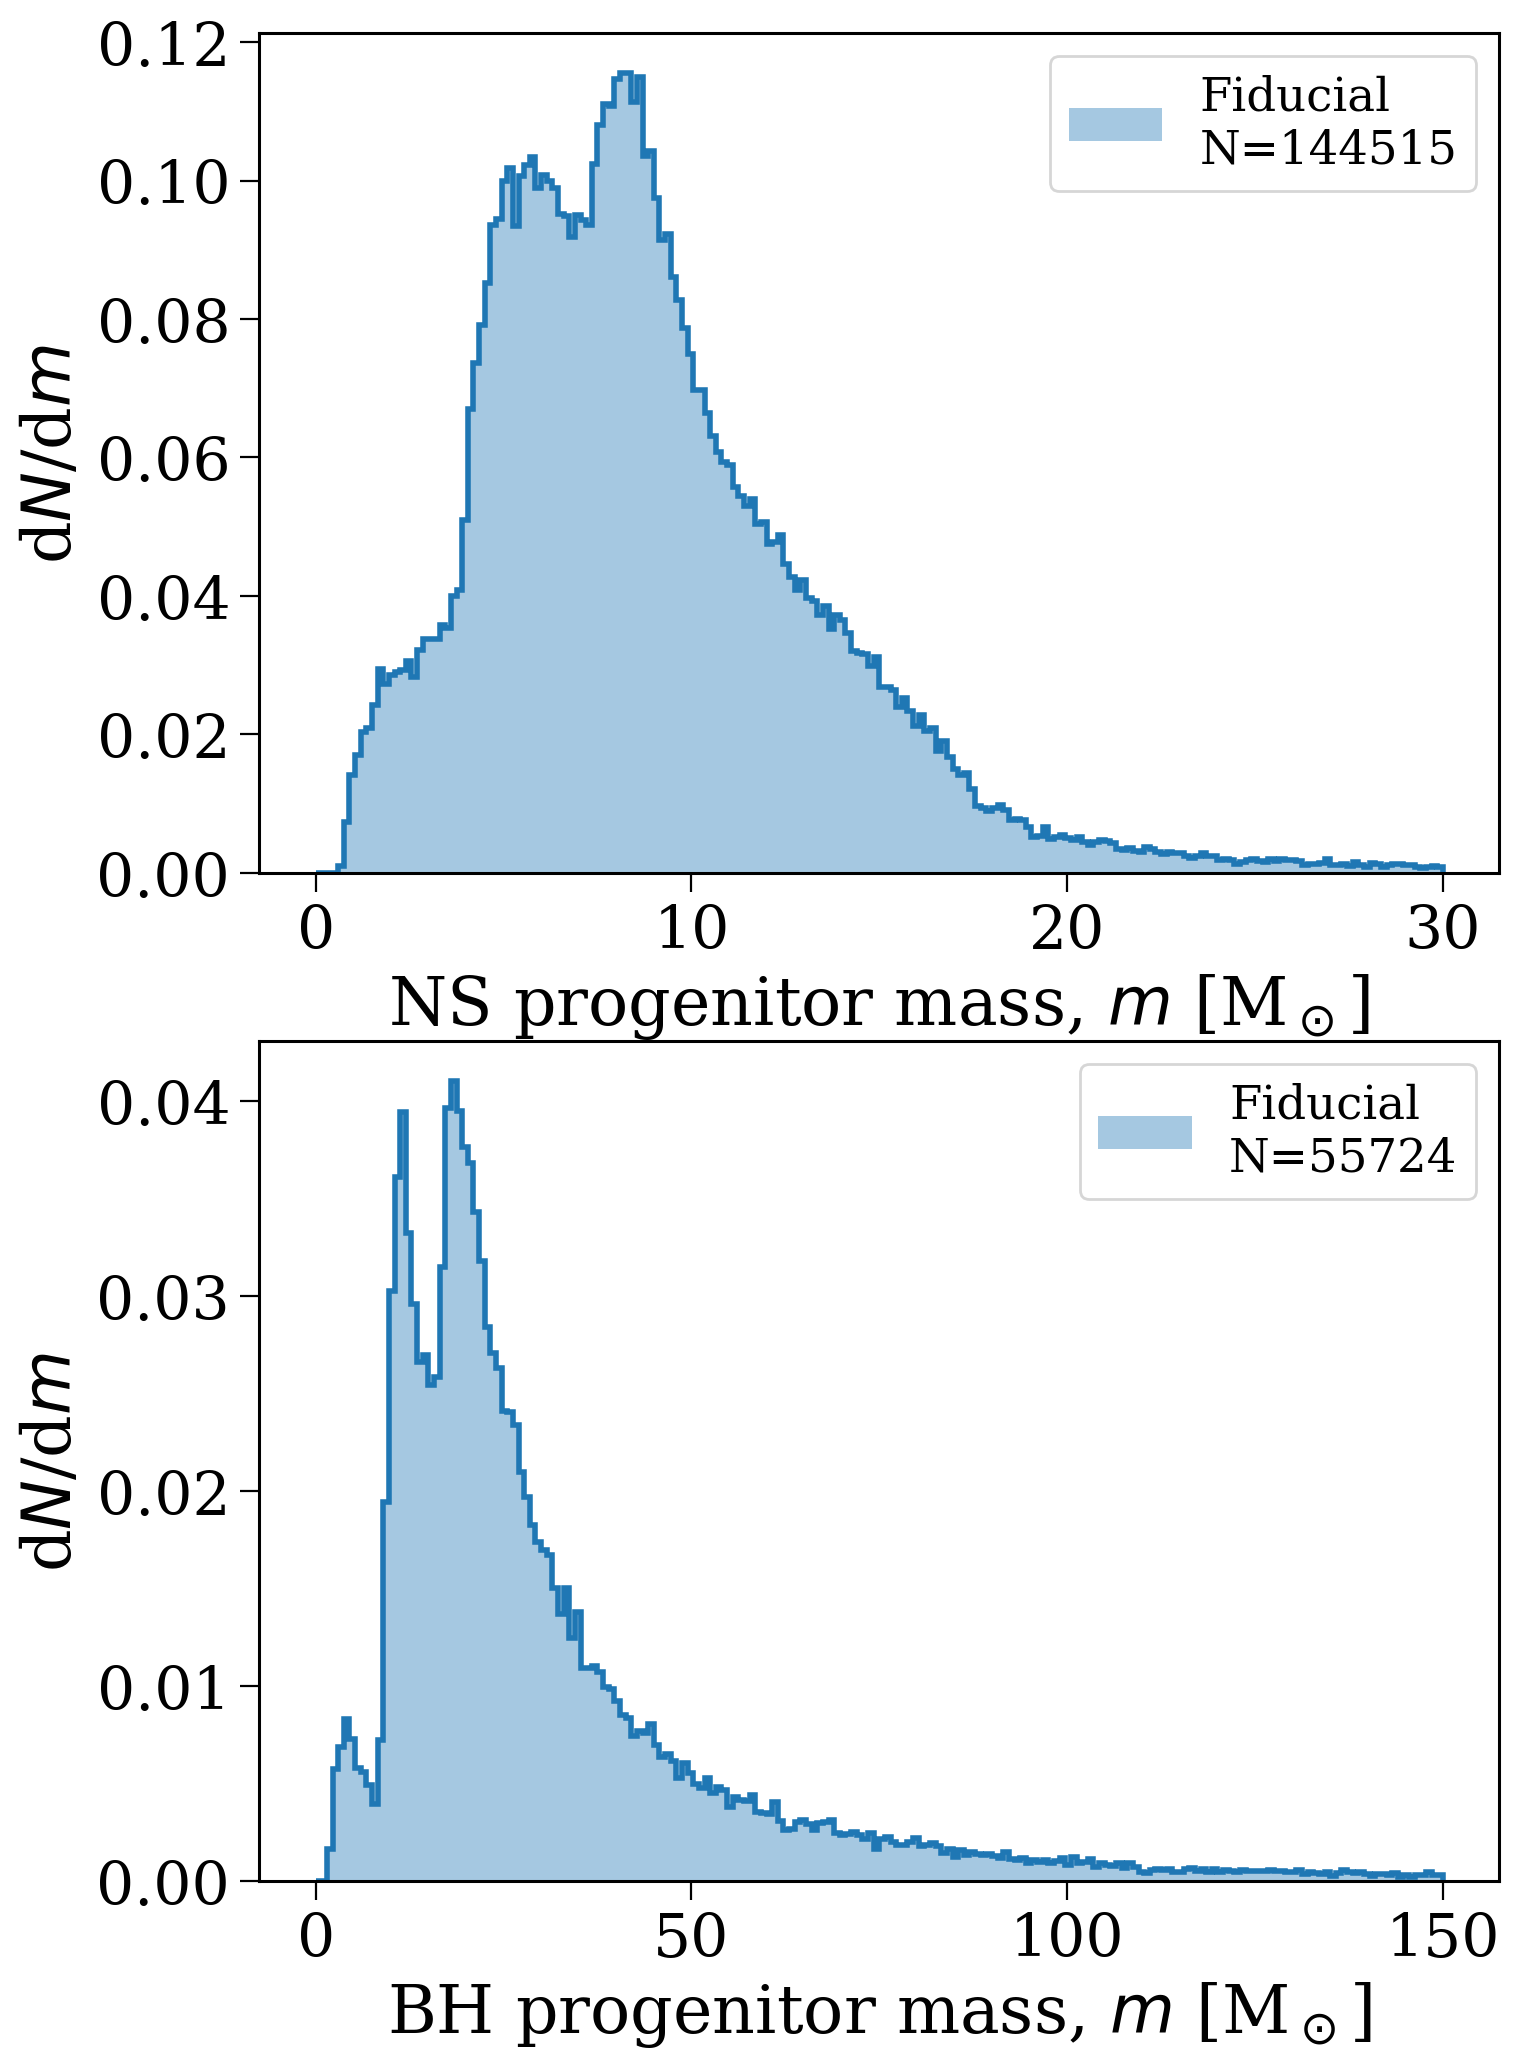

In [69]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 201), np.linspace(0, 150, 201)]):
    plotting.compare_table_quantity(
        pops=[pop],
        table_name="initC",
        quantity="mass",
        kstar=kstar,
        bins=bins,
        xlabel=f"{co_type} progenitor mass, $m$ [M$_\odot$]",
        ylabel=f"d$N$/d$m$",
        density=True,
        ax=ax,
        fig=fig,
        show=False
    )

plt.savefig("../plots/progenitor_masses.pdf", format="pdf", bbox_inches='tight')
plt.show()

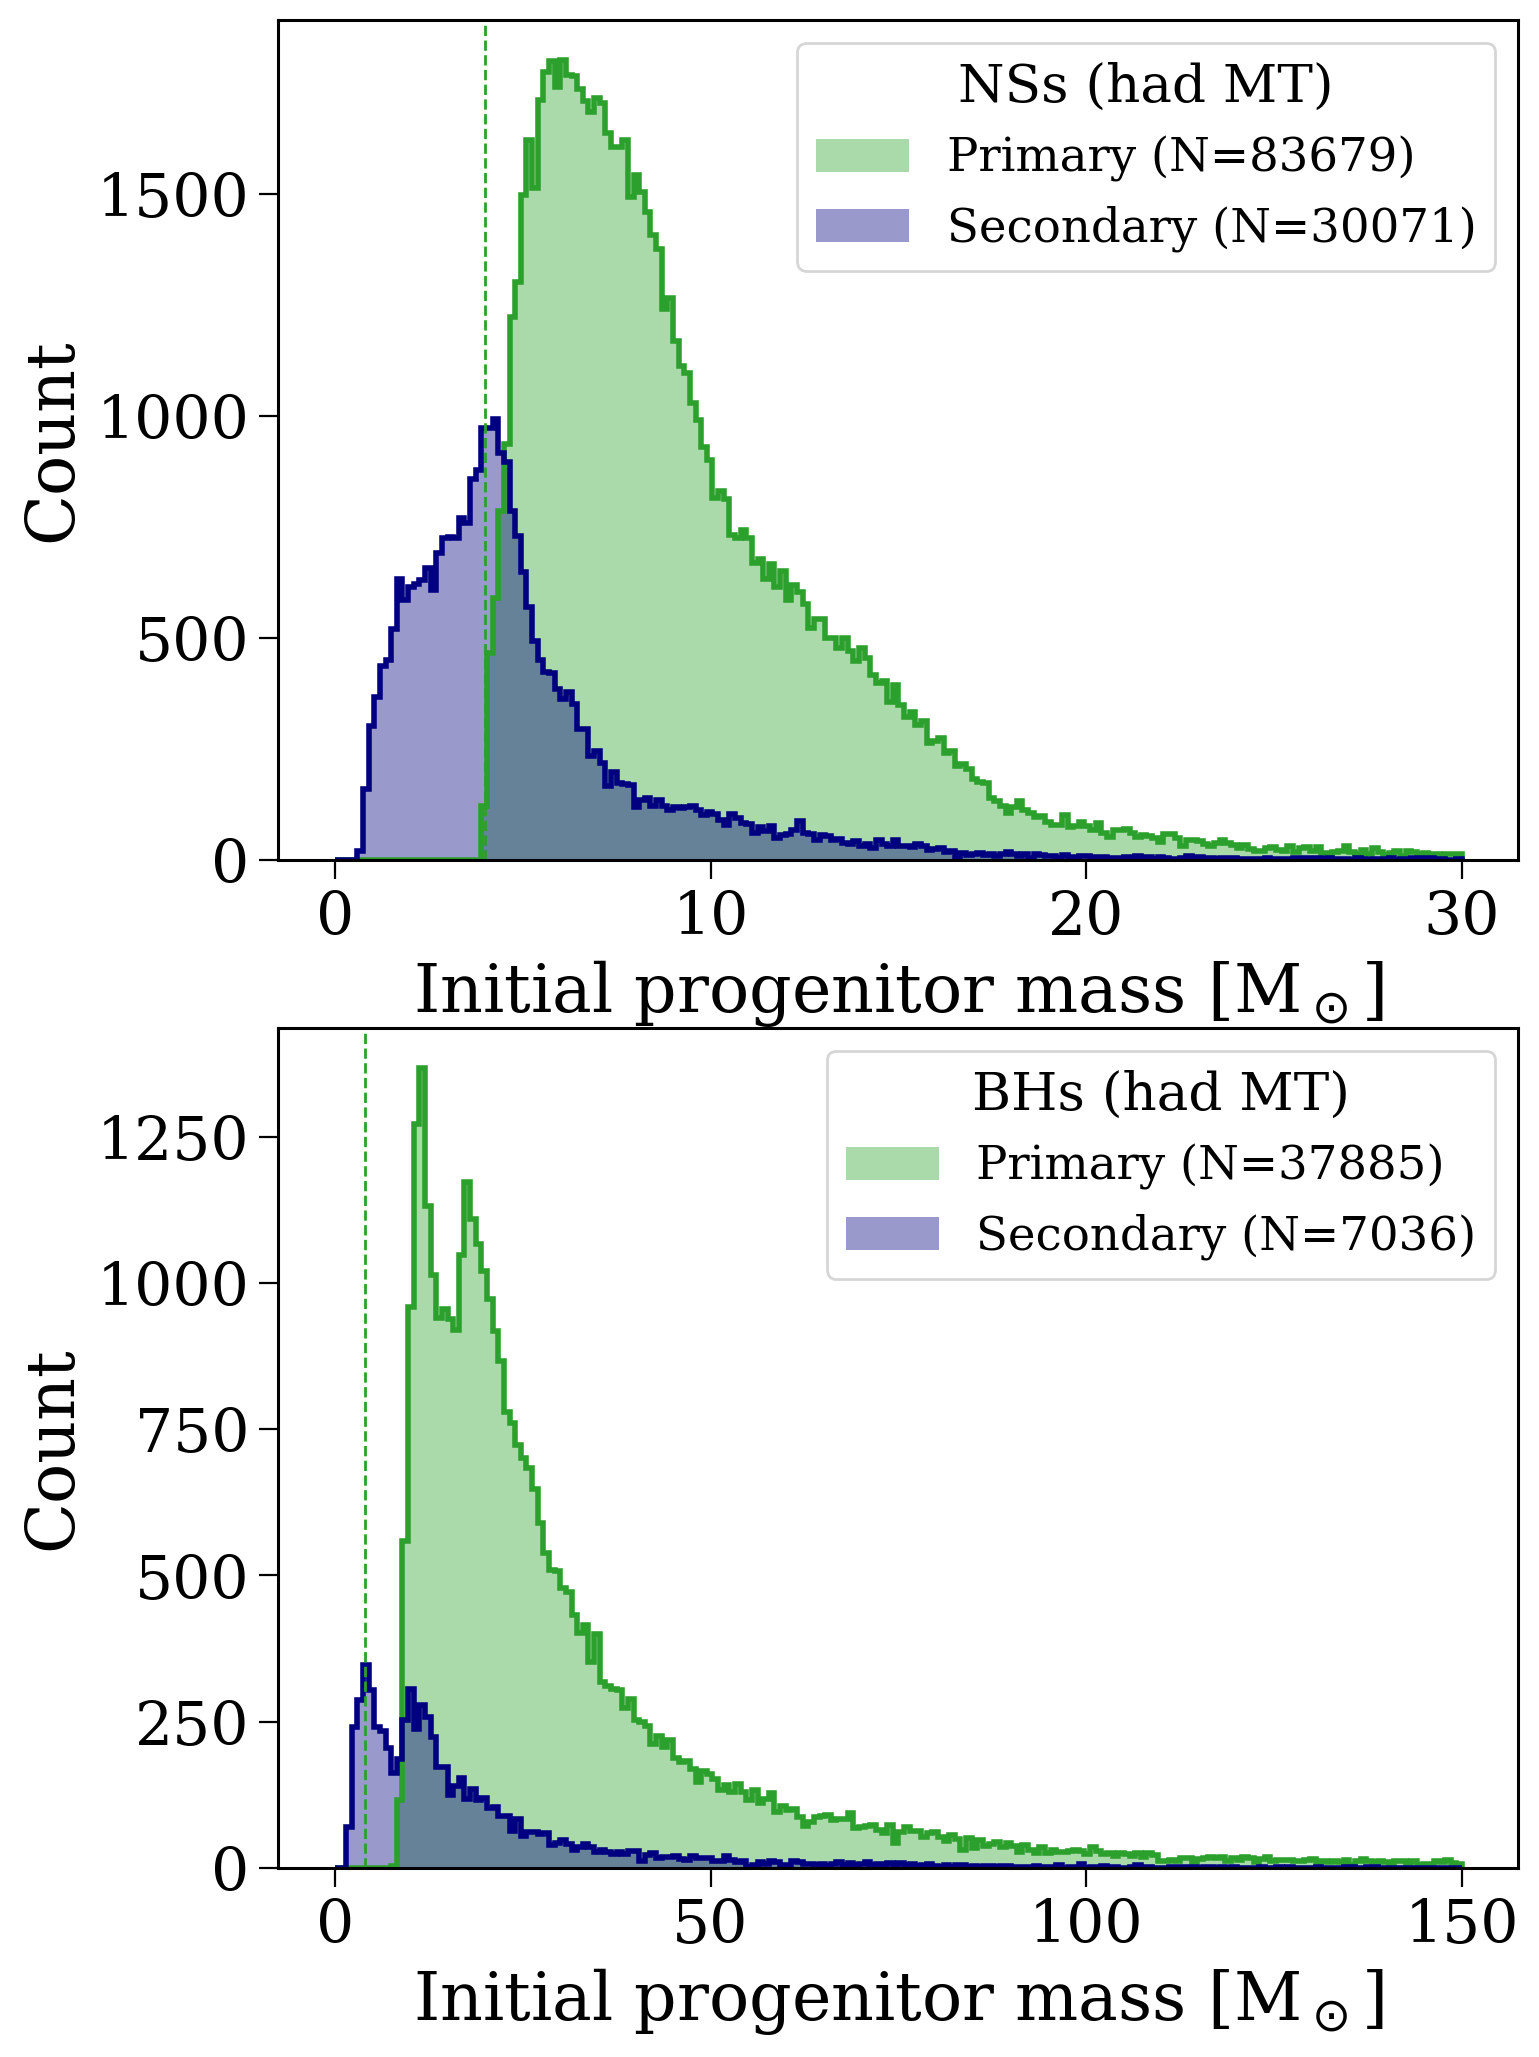

In [70]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 201), np.linspace(0, 150, 201)]):
    for comp, colour, label in zip(["1", "2"], ["tab:green", "navy"], ["Primary", "Secondary"]):
        experienced_mt = pop.bpp[pop.bpp["evol_type"] == 3]["bin_num"]
        experienced_ce = pop.bpp[pop.bpp["evol_type"] == 7]["bin_num"]

        init_masses = pop.initC[f"mass_{comp}"][(
            (pop.final_bpp[f"kstar_{comp}"] == kstar)
            & (pop.final_bpp["bin_num"].isin(experienced_mt))
            # & ~(pop.final_bpp["bin_num"].isin(experienced_ce))
        )]

        ax.hist(init_masses, bins=bins, histtype='step', lw=2, color=colour)
        ax.hist(init_masses, bins=bins, alpha=0.4, color=colour,
                label=f"{label} (N={len(init_masses)})")
        
    ax.axvline(4, color="tab:green", ls='--', lw=1)

    ax.set(
        xlabel=f"Initial progenitor mass [M$_\odot$]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s (had MT)")

plt.savefig("../plots/progenitor_masses_mt.pdf", format="pdf", bbox_inches='tight')
plt.show()

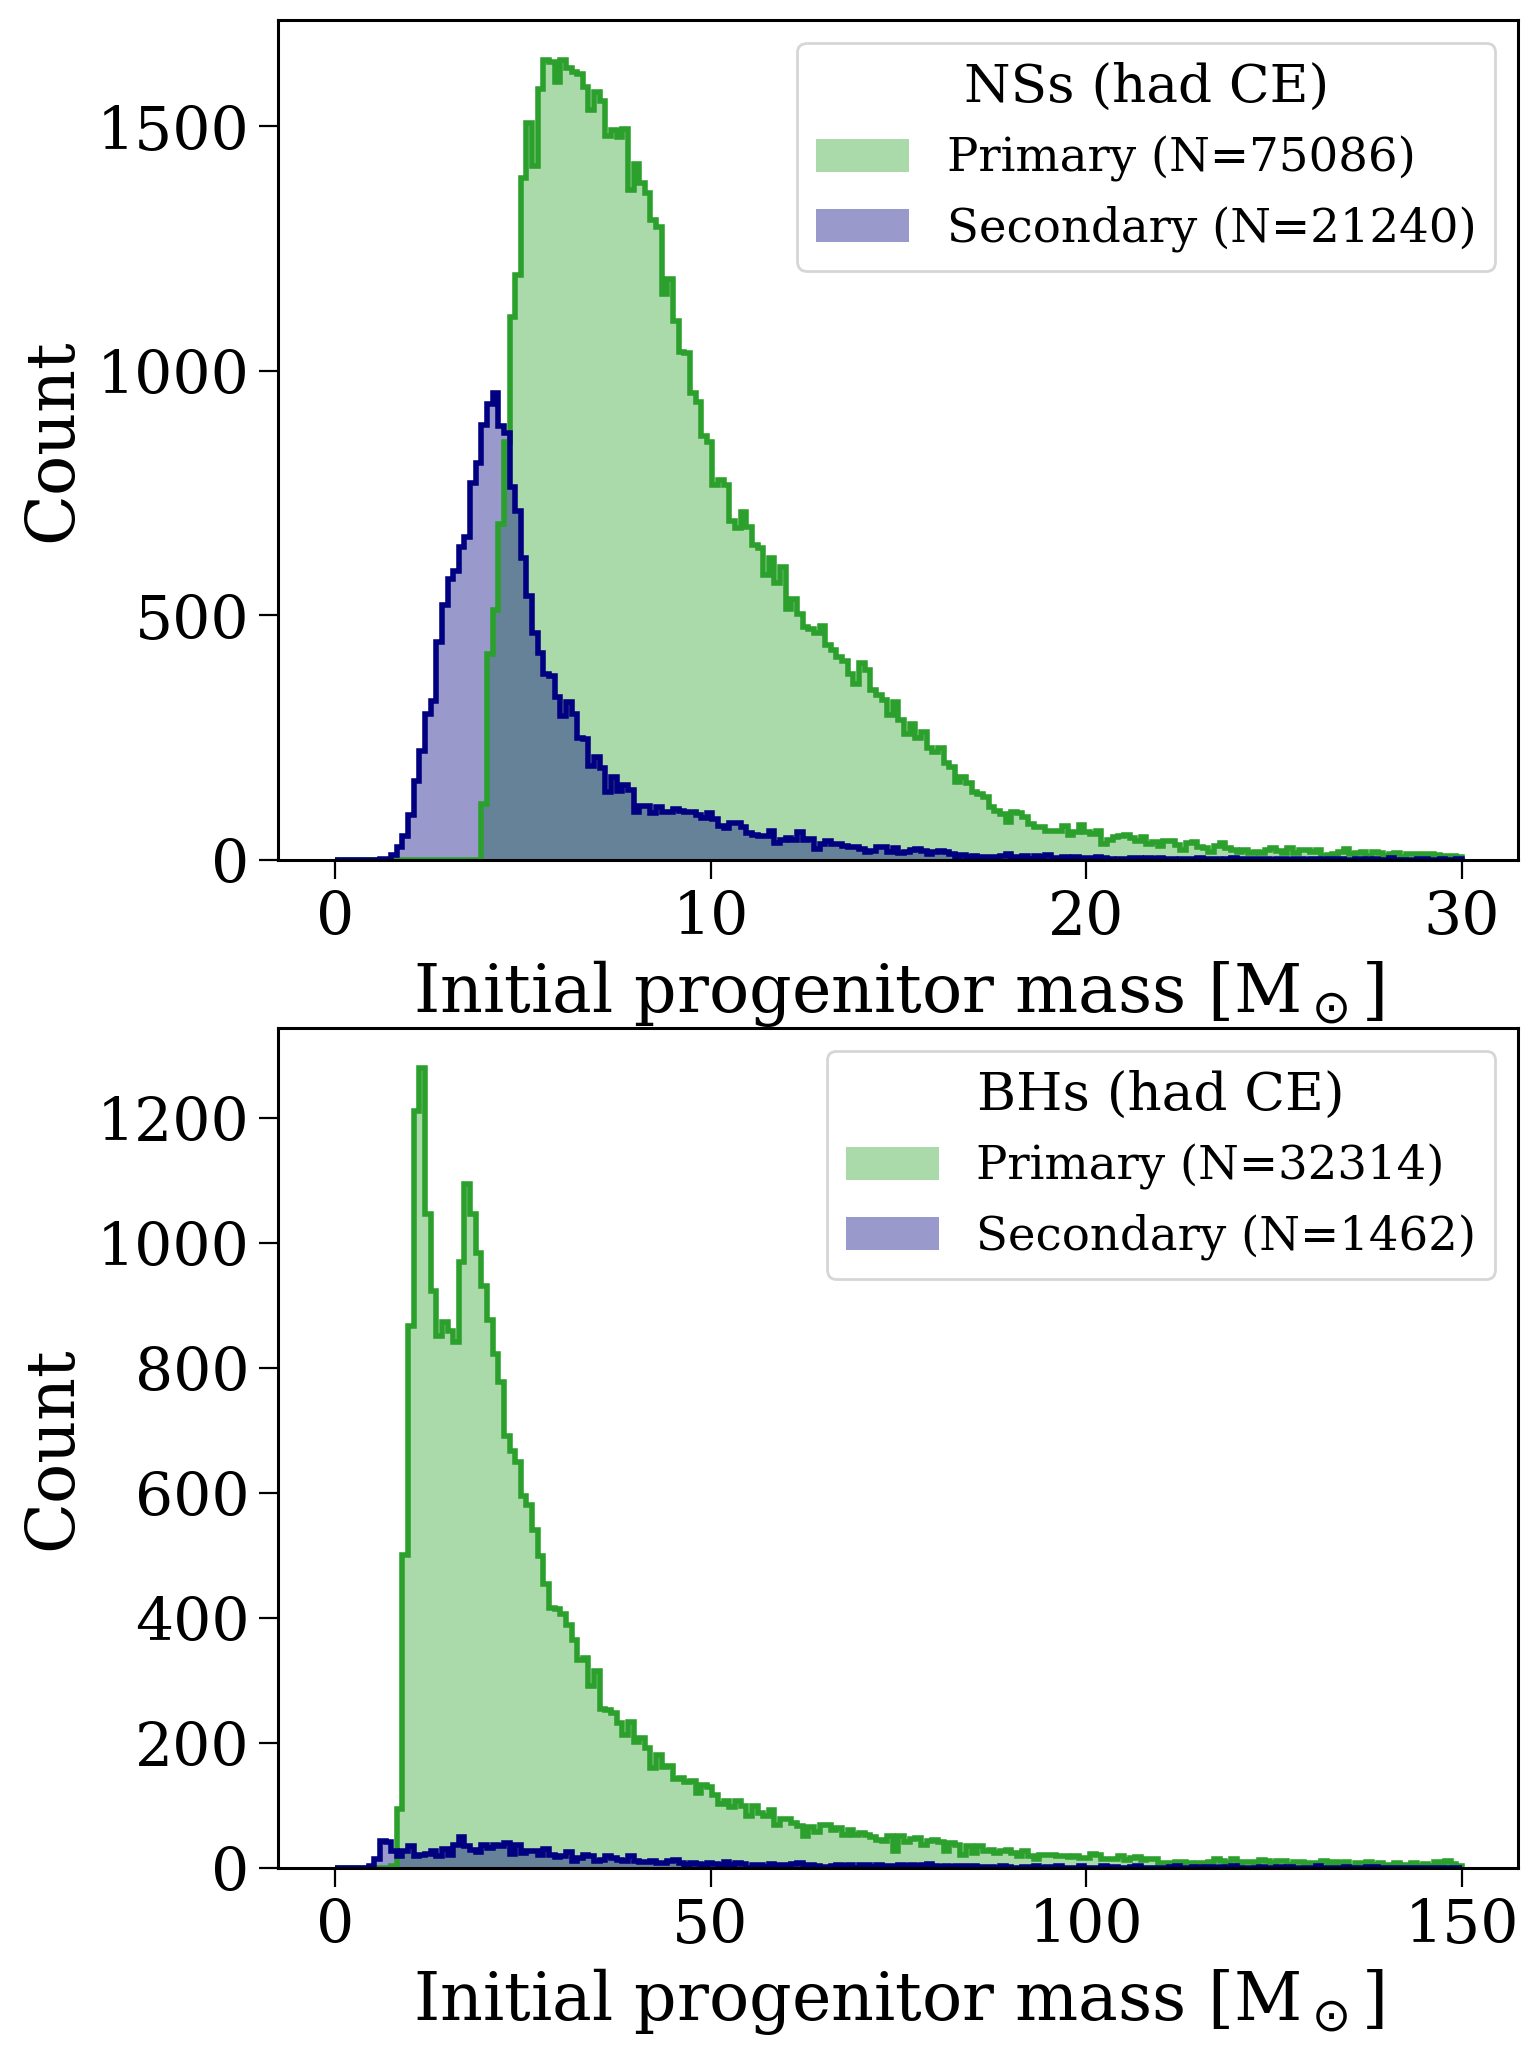

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(8, 12))

for ax, co_type, kstar, bins in zip(axes, ['NS', 'BH'], [13, 14],
                                    [np.linspace(0, 30, 201), np.linspace(0, 150, 201)]):
    for comp, colour, label in zip(["1", "2"], ["tab:green", "navy"], ["Primary", "Secondary"]):
        experienced_mt = pop.bpp[pop.bpp["evol_type"] == 3]["bin_num"]
        experienced_ce = pop.bpp[pop.bpp["evol_type"] == 7]["bin_num"]

        init_masses = pop.initC[f"mass_{comp}"][(
            (pop.final_bpp[f"kstar_{comp}"] == kstar)
            & (pop.final_bpp["bin_num"].isin(experienced_mt))
            & (pop.final_bpp["bin_num"].isin(experienced_ce))
        )]

        ax.hist(init_masses, bins=bins, histtype='step', lw=2, color=colour)
        ax.hist(init_masses, bins=bins, alpha=0.4, color=colour,
                label=f"{label} (N={len(init_masses)})")

    ax.set(
        xlabel=f"Initial progenitor mass [M$_\odot$]",
        ylabel="Count"
    )
    ax.legend(title=f"{co_type}s (had CE)")

plt.savefig("../plots/progenitor_masses_ce.pdf", format="pdf", bbox_inches='tight')
plt.show()

# Nearest COs

In [72]:
masses["CO"]

array([ 1.27758353,  1.27758353,  1.27758353, ..., 13.34288123,
        5.07244356,  6.41699373], shape=(200239,))

In [73]:
kinematics["Fiducial"]["pos"]["NS"].shape

(144515, 3)

In [74]:
init_m_tot = pop.initC["mass_1"] + pop.initC["mass_2"]

In [75]:
pop.initial_galaxy.x

<Quantity [ 2.00338092, -1.48413055,  2.36772207, ...,  3.29535593,
           -3.34655158,  0.48398618] kpc>

In [76]:
pop.initial_galaxy.positions.T

<Quantity [[ 2.00338092, -4.34515002,  0.06141299],
           [-1.48413055,  3.71058435, -0.08110006],
           [ 2.36772207, -7.00534276,  0.49677578],
           ...,
           [ 3.29535593, 18.74812082, -0.21917393],
           [-3.34655158, -0.4088488 , -0.64449231],
           [ 0.48398618,  2.6636708 ,  0.11637134]] kpc>

In [77]:
def get_solar_neighbourhood_density(pos, masses, major_axis=8*u.kpc, minor_axis=0.2*u.kpc):
    R = np.sqrt(pos[:, 0]**2 + pos[:, 1]**2)
    z = pos[:, 2]
    torus_mask = ((R - major_axis)**2 + z**2) <= minor_axis**2

    n_in_torus = torus_mask.sum()

    # mass contained in torus
    mass_in_torus = masses[torus_mask].sum() * u.Msun

    # density of COs in torus in pc^-3
    torus_volume = 2 * np.pi**2 * major_axis * minor_axis**2
    co_density = n_in_torus / torus_volume.to(u.pc**3)
    co_mass_density = mass_in_torus / torus_volume.to(u.pc**3)

    return co_density, co_mass_density

In [78]:
for co_type in ["CO", "NS", "BH"]:
    co_density, co_mass_density = get_solar_neighbourhood_density(
        kinematics["Fiducial"]["pos"][co_type],
        masses[co_type]
    )
    co_density *= scale_up
    co_mass_density *= scale_up
    nearest_distance = (3 / (4 * np.pi * co_density))**(1/3)
    print(f"{co_type} density: {co_density:.1e}, mass density: {co_mass_density:.1e}, nearest neighbour distance: {nearest_distance:.1f}")

CO density: 3.8e-04 1 / pc3, mass density: 2.3e-03 solMass / pc3, nearest neighbour distance: 8.5 pc
NS density: 2.2e-04 1 / pc3, mass density: 3.2e-04 solMass / pc3, nearest neighbour distance: 10.3 pc
BH density: 1.7e-04 1 / pc3, mass density: 2.0e-03 solMass / pc3, nearest neighbour distance: 11.3 pc
